# Paper-guided RA/OA ECM-cell spatial analysis

This notebook uses the RA/OA CellDIVE dataset to demonstrate the ECM-cell functions in `spatioev/spatial` against the biological model from Richard et al. 2025, *Synovial matrix turnover controls immune cell spatial patterning in inflammation resolution*.

The paper's spatial ideas are translated into five analysis blocks:

1. **COL6 immune exclusion / immune-permissive zones**: are lymphocytes and myeloid subsets differentially close to COL6A1 fibers?
2. **COL6-rich versus COL6-poor regions**: can local COL6A1 fiber density reproduce the paper's COL6 dark-zone idea?
3. **Cell-ECM spatial association across scales**: use cross Ripley's K to ask at what spatial scales selected immune subsets associate with or avoid ECM types.
4. **ECM organization in RA versus OA**: use fiber Moran's I to quantify whether ECM morphology is spatially structured.
5. **ECM-cell coupling**: use cross Moran's I to test whether ECM structure is coupled to nearby immune-cell niches.

Permutation-heavy and graph-niche analyses are included as optional sections because they can be expensive on the full dataset.

In [1]:
from pathlib import Path
import importlib.util

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy.stats import fisher_exact, mannwhitneyu
from shapely import concave_hull, contains_xy
from shapely.geometry import MultiPoint, Polygon, MultiPolygon
from shapely.ops import unary_union
from shapely.validation import make_valid
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data" / "RA_OA"
RESULTS_DIR = PROJECT_ROOT / "notebooks" / "results" / "ra_oa_ecm_cell"
ANALYSIS_DIR = RESULTS_DIR / "paper_guided_outputs"
FIGURES_DIR = RESULTS_DIR / "figures" / "01_paper_guided_analysis"
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

ADATA_PATH = DATA_DIR / "tmp6.h5ad"
FIBER_PATH = RESULTS_DIR / "ra_oa_fiber_df.pkl"
LINKS_PATH = RESULTS_DIR / "ra_oa_cell_fiber_links.pkl"

PIXEL_SIZE_UM = 0.325
LINK_RADIUS_UM = 50
LINK_RADIUS_PX = LINK_RADIUS_UM / PIXEL_SIZE_UM
IMAGE_KEY = "imageid"
PHENOTYPE_KEY = "phenotype"
GROUP_KEY = "pathology"
FIBER_TYPE_KEY = "fiber_type"

sns.set_theme(style="white", context="notebook")
pd.set_option("display.max_columns", 80)
print("Project root:", PROJECT_ROOT)
print("Analysis dir:", ANALYSIS_DIR)
print("Figures dir:", FIGURES_DIR)

Project root: /Users/shihongwu/SpatioEv
Analysis dir: /Users/shihongwu/SpatioEv/notebooks/results/ra_oa_ecm_cell/paper_guided_outputs
Figures dir: /Users/shihongwu/SpatioEv/notebooks/results/ra_oa_ecm_cell/figures/01_paper_guided_analysis


In [2]:
# Import the ECM modules directly by file path. This keeps the notebook focused
# on ECM-cell analysis and avoids optional top-level package dependencies.
def load_module(module_name, relative_path):
    module_path = PROJECT_ROOT / relative_path
    spec = importlib.util.spec_from_file_location(module_name, module_path)
    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)
    return module


ecm_stats = load_module("spatial_ecm_stats", "spatioev/spatial/spatial_ecm_stats.py")
ecm_graph = load_module("spatial_ecm_graph", "spatioev/spatial/spatial_ecm_graph.py")

cell_to_fiber_distance = ecm_stats.cell_to_fiber_distance
fiber_density_near_cells = ecm_stats.fiber_density_near_cells
ecm_cross_ripleys_k = ecm_stats.cross_ripleys_k
cross_ripleys_k_permutation_envelope = ecm_stats.cross_ripleys_k_permutation_envelope
morans_i_fibers = ecm_stats.morans_i_fibers
local_morans_i_fibers = ecm_stats.local_morans_i_fibers
cross_morans_i_ecm_cells = ecm_stats.cross_morans_i_ecm_cells
cross_morans_i_ecm_cells_permutation_test = ecm_stats.cross_morans_i_ecm_cells_permutation_test
map_cells_to_fibers = ecm_stats.map_cells_to_fibers
map_cells_to_fibers_kernel = ecm_stats.map_cells_to_fibers_kernel
local_cross_morans_i_ecm_cells = ecm_stats.local_cross_morans_i_ecm_cells

build_ecm_bipartite_graph_per_image = ecm_graph.build_ecm_bipartite_graph_per_image
project_fiber_graph_per_image = ecm_graph.project_fiber_graph_per_image
detect_ecm_niches_per_image = ecm_graph.detect_ecm_niches_per_image
assign_niches_to_fibers = ecm_graph.assign_niches_to_fibers
compute_invasion_score = ecm_graph.compute_invasion_score
print("Imported ECM analysis functions by file path.")

Imported ECM analysis functions by file path.


In [3]:
class ObsOnlyAnnData:
    """Small wrapper for functions that only need `adata.obs`."""

    def __init__(self, obs):
        self.obs = obs


def read_obs_only(h5ad_path):
    backed = ad.read_h5ad(h5ad_path, backed="r")
    obs = backed.obs.copy()
    backed.file.close()
    return ObsOnlyAnnData(obs)


def subset_obs_adata(adata, mask):
    return ObsOnlyAnnData(adata.obs.loc[mask].copy())


def safe_label(value):
    return str(value).replace(" ", "_").replace("+", "pos").replace("/", "_").replace("-", "_")


adata = read_obs_only(ADATA_PATH)
fiber_df = pd.read_pickle(FIBER_PATH)
links_df = pd.read_pickle(LINKS_PATH)

print("Cells:", adata.obs.shape)
print("Fibers:", fiber_df.shape)
print("Links:", links_df.shape)
display(adata.obs[[IMAGE_KEY, PHENOTYPE_KEY, GROUP_KEY, "X_centroid", "Y_centroid"]].head())
display(fiber_df[[IMAGE_KEY, FIBER_TYPE_KEY, GROUP_KEY, "X_centroid", "Y_centroid"]].head())

Cells: (662388, 90)
Fibers: (548442, 14)
Links: (22495433, 4)


,imageid,phenotype,pathology,X_centroid,Y_centroid
JRP112_0,JRP112,Other Immune cells,RA,13100.311872,185.782437
JRP112_1,JRP112,Non-immune cells,RA,14070.780340,467.928398
JRP112_2,JRP112,Other Immune cells,RA,14004.151738,487.922460
JRP112_3,JRP112,Non-immune cells,RA,14098.755780,515.580925
JRP112_4,JRP112,Other Immune cells,RA,14141.346939,517.469388


,imageid,fiber_type,pathology,X_centroid,Y_centroid
fiber_id,,,,,
JRP112__CHP__fov0__1__0,JRP112,CHP,RA,13274.571421,2227.188800
JRP112__CHP__fov0__3__1,JRP112,CHP,RA,13953.946667,666.513778
JRP112__CHP__fov0__4__2,JRP112,CHP,RA,13900.070991,821.755508
JRP112__CHP__fov0__5__3,JRP112,CHP,RA,13993.943005,950.569948
JRP112__CHP__fov0__6__4,JRP112,CHP,RA,13722.457143,1106.382937


In [4]:
SAMPLE_IDS = sorted(adata.obs[IMAGE_KEY].dropna().unique())
FIBER_TYPES = sorted(fiber_df[FIBER_TYPE_KEY].dropna().unique())
EXISTING_PHENOTYPES = sorted(adata.obs[PHENOTYPE_KEY].dropna().unique())

PAPER_CELL_TYPES = [
    "Monocytes",
    "Macrophages",
    "MERTK+ Macrophages",
    "Dendritic cells",
    "CD4 T cells",
    "CD8 T cells",
    "T cells",
    "B cells",
    "Plasma cells",
    "Neutrophils",
    "Vascular cells",
]
PAPER_CELL_TYPES = [p for p in PAPER_CELL_TYPES if p in EXISTING_PHENOTYPES]

PAPER_FIBER_TYPES = ["COL6A1", "COL4A1", "CHP", "FN", "COL1A1bis", "MFAP5"]
PAPER_FIBER_TYPES = [f for f in PAPER_FIBER_TYPES if f in FIBER_TYPES]

FIBER_FEATURES = [
    "alignment_score",
    "area",
    "major_axis_length",
    "minor_axis_length",
    "eccentricity",
]
FIBER_FEATURES = [f for f in FIBER_FEATURES if f in fiber_df.columns]

RIPLEY_RADII_UM = np.array([10, 20, 30, 40, 50], dtype=float)
RIPLEY_RADII_PX = RIPLEY_RADII_UM / PIXEL_SIZE_UM
KNN_K = 8
CELL_FIBER_BANDWIDTH_UM = 30
CELL_FIBER_BANDWIDTH_PX = CELL_FIBER_BANDWIDTH_UM / PIXEL_SIZE_UM

print("Samples:", SAMPLE_IDS)
print("Paper-guided fiber types:", PAPER_FIBER_TYPES)
print("Paper-guided cell types:", PAPER_CELL_TYPES)
print("Fiber morphology features:", FIBER_FEATURES)

Samples: ['JRP112', 'JRP122', 'JRP141', 'JRP144', 'S00292623', 'S00293087']
Paper-guided fiber types: ['COL6A1', 'COL4A1', 'CHP', 'FN', 'COL1A1bis', 'MFAP5']
Paper-guided cell types: ['Monocytes', 'Macrophages', 'MERTK+ Macrophages', 'Dendritic cells', 'CD4 T cells', 'CD8 T cells', 'T cells', 'B cells', 'Plasma cells', 'Neutrophils', 'Vascular cells']
Fiber morphology features: ['alignment_score', 'area', 'major_axis_length', 'minor_axis_length', 'eccentricity']


In [5]:
def savefig(fig, filename):
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / filename, dpi=300, bbox_inches="tight")


def plot_ra_oa_box(df, x, y, title, filename, order=None, hue=GROUP_KEY, figsize=(8, 4), rotate=45):
    plot_df = df.dropna(subset=[x, y, hue]).copy()
    if plot_df.empty:
        print("No data for", title)
        return None
    fig, ax = plt.subplots(figsize=figsize)
    sns.boxplot(data=plot_df, x=x, y=y, hue=hue, order=order, showfliers=False, ax=ax)
    sns.stripplot(data=plot_df, x=x, y=y, hue=hue, order=order, dodge=True, color="black", alpha=0.45, size=3, legend=False, ax=ax)
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=rotate)
    sns.despine(ax=ax)
    savefig(fig, filename)
    plt.show()
    return ax


def plot_heatmap(df, row, col, value, title, filename, figsize=(8, 5), center=0):
    plot_df = df.dropna(subset=[row, col, value]).copy()
    if plot_df.empty:
        print("No data for", title)
        return None
    matrix = plot_df.pivot_table(index=row, columns=col, values=value, aggfunc="mean")
    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(matrix, cmap="vlag", center=center, linewidths=0.3, linecolor="white", ax=ax)
    ax.set_title(title)
    ax.set_xlabel(col)
    ax.set_ylabel(row)
    savefig(fig, filename)
    plt.show()
    return ax


def summarize_ra_oa(sample_df, value_col, group_cols):
    sample_cols = [IMAGE_KEY, GROUP_KEY] + group_cols
    sample_level = (
        sample_df
        .dropna(subset=[value_col])
        .groupby(sample_cols, observed=True)[value_col]
        .mean()
        .reset_index()
    )

    rows = []
    for keys, sub in sample_level.groupby(group_cols, observed=True):
        if not isinstance(keys, tuple):
            keys = (keys,)
        ra = sub.loc[sub[GROUP_KEY].eq("RA"), value_col].dropna()
        oa = sub.loc[sub[GROUP_KEY].eq("OA"), value_col].dropna()
        if len(ra) > 0 and len(oa) > 0:
            try:
                _, p_value = mannwhitneyu(ra, oa, alternative="two-sided")
            except ValueError:
                p_value = np.nan
        else:
            p_value = np.nan

        row = dict(zip(group_cols, keys))
        row.update({
            "n_RA": len(ra),
            "n_OA": len(oa),
            "mean_RA": ra.mean() if len(ra) else np.nan,
            "mean_OA": oa.mean() if len(oa) else np.nan,
            "RA_minus_OA": (ra.mean() - oa.mean()) if len(ra) and len(oa) else np.nan,
            "p_value_mannwhitney": p_value,
        })
        rows.append(row)

    return pd.DataFrame(rows).sort_values("RA_minus_OA", ascending=False)


def add_pair_label(df):
    df = df.copy()
    df["cell_fiber_pair"] = df[PHENOTYPE_KEY].astype(str) + " vs " + df[FIBER_TYPE_KEY].astype(str)
    return df

In [ ]:
def area_px2_to_mm2(area_px2):
    return area_px2 * (PIXEL_SIZE_UM ** 2) / 1e6


def clean_geometry(geom):
    if geom is None or geom.is_empty:
        return None
    geom = make_valid(geom)
    if geom.is_empty:
        return None
    return geom


def make_point_region_geometry(coords, concavity=0.25, expand_px=0):
    """Build a compact polygon-like region from point coordinates."""
    coords = np.asarray(coords, dtype=float)
    coords = coords[np.isfinite(coords).all(axis=1)]

    if len(coords) == 0:
        return None

    points = MultiPoint(coords)
    if len(coords) < 3:
        geom = points.buffer(max(expand_px, 1.0))
    else:
        try:
            geom = concave_hull(points, ratio=concavity, allow_holes=False)
        except Exception:
            geom = points.convex_hull
        if expand_px and expand_px > 0:
            geom = geom.buffer(expand_px)

    return clean_geometry(geom)


def build_zone_component_regions(
    zone_fibers,
    zone_key,
    region_eps_px,
    region_expand_px,
    min_samples=5,
    min_cluster_size=20,
    concavity=0.25,
):
    """Cluster zone-specific fibers and convert each component into a spatial region."""
    rows = []
    if zone_fibers.empty:
        return pd.DataFrame()

    for (img, zone), sub in zone_fibers.groupby([IMAGE_KEY, zone_key], observed=True):
        sub = sub.dropna(subset=["X_centroid", "Y_centroid"]).copy()
        if len(sub) < min_cluster_size:
            continue

        coords = sub[["X_centroid", "Y_centroid"]].to_numpy(dtype=float)
        labels = DBSCAN(eps=region_eps_px, min_samples=min_samples).fit_predict(coords)
        cluster_labels = [lab for lab in np.unique(labels) if lab != -1]

        # If DBSCAN is too strict for this sample/zone, still keep a broad region
        # so the area-normalized analysis remains available for QC.
        if len(cluster_labels) == 0 and len(sub) >= min_cluster_size:
            labels = np.zeros(len(sub), dtype=int)
            cluster_labels = [0]

        pathology = sub[GROUP_KEY].dropna().mode().iloc[0] if sub[GROUP_KEY].notna().any() else np.nan

        for lab in cluster_labels:
            member_mask = labels == lab
            if member_mask.sum() < min_cluster_size:
                continue
            cluster = sub.iloc[np.where(member_mask)[0]]
            geom = make_point_region_geometry(
                cluster[["X_centroid", "Y_centroid"]].to_numpy(),
                concavity=concavity,
                expand_px=region_expand_px,
            )
            if geom is None:
                continue

            rows.append({
                IMAGE_KEY: img,
                GROUP_KEY: pathology,
                zone_key: zone,
                "region_id": f"{img}__{zone}__{lab}",
                "n_fibers": len(cluster),
                "geometry": geom,
                "area_px2": geom.area,
                "area_mm2": area_px2_to_mm2(geom.area),
            })

    return pd.DataFrame(rows)


def union_zone_regions(region_components, zone_key, include_overlap=True):
    """Union component regions by image/zone and remove rich-poor overlap for density estimates."""
    if region_components.empty:
        return pd.DataFrame()

    union_rows = []
    for (img, zone), sub in region_components.groupby([IMAGE_KEY, zone_key], observed=True):
        geoms = [g for g in sub["geometry"] if g is not None and not g.is_empty]
        if not geoms:
            continue
        geom = clean_geometry(unary_union(geoms))
        if geom is None:
            continue
        pathology = sub[GROUP_KEY].dropna().mode().iloc[0] if sub[GROUP_KEY].notna().any() else np.nan
        union_rows.append({
            IMAGE_KEY: img,
            GROUP_KEY: pathology,
            zone_key: zone,
            "region_id": f"{img}__{zone}",
            "n_components": len(sub),
            "n_fibers": sub["n_fibers"].sum(),
            "geometry": geom,
        })

    union_df = pd.DataFrame(union_rows)
    if union_df.empty:
        return union_df

    final_rows = []
    for img, sub in union_df.groupby(IMAGE_KEY, observed=True):
        by_zone = {row[zone_key]: row for _, row in sub.iterrows()}
        rich = by_zone.get("COL6A1-rich")
        poor = by_zone.get("COL6A1-poor")
        overlap = None
        if rich is not None and poor is not None:
            overlap = clean_geometry(rich["geometry"].intersection(poor["geometry"]))

        for zone, row in by_zone.items():
            geom = row["geometry"]
            if overlap is not None and not overlap.is_empty:
                geom = clean_geometry(geom.difference(overlap))
            if geom is None:
                continue
            out = row.to_dict()
            out["geometry"] = geom
            out["area_px2"] = geom.area
            out["area_mm2"] = area_px2_to_mm2(geom.area)
            out["region_class"] = "unique"
            final_rows.append(out)

        if include_overlap and overlap is not None and not overlap.is_empty:
            pathology = sub[GROUP_KEY].dropna().mode().iloc[0] if sub[GROUP_KEY].notna().any() else np.nan
            final_rows.append({
                IMAGE_KEY: img,
                GROUP_KEY: pathology,
                zone_key: "COL6A1-overlap",
                "region_id": f"{img}__COL6A1-overlap",
                "n_components": np.nan,
                "n_fibers": np.nan,
                "geometry": overlap,
                "area_px2": overlap.area,
                "area_mm2": area_px2_to_mm2(overlap.area),
                "region_class": "overlap",
            })

    return pd.DataFrame(final_rows)


def contains_points(geom, x, y):
    if geom is None or geom.is_empty:
        return np.zeros(len(x), dtype=bool)
    try:
        return contains_xy(geom, np.asarray(x, dtype=float), np.asarray(y, dtype=float))
    except Exception:
        return np.array([geom.contains(pt) for pt in MultiPoint(np.c_[x, y]).geoms])


def summarize_cells_in_regions(obs, region_df, region_key, phenotypes):
    """Count cells and area-normalized cell density in each region."""
    rows = []
    if region_df.empty:
        return pd.DataFrame()

    for _, region in region_df.iterrows():
        if region.get("region_class", "unique") == "overlap":
            continue
        cells = obs.loc[obs[IMAGE_KEY].eq(region[IMAGE_KEY])].copy()
        mask = contains_points(region["geometry"], cells["X_centroid"], cells["Y_centroid"])
        cells = cells.loc[mask]
        area_mm2 = region["area_mm2"]

        for phenotype in phenotypes:
            n_cells = int(cells[PHENOTYPE_KEY].eq(phenotype).sum())
            rows.append({
                IMAGE_KEY: region[IMAGE_KEY],
                GROUP_KEY: region[GROUP_KEY],
                region_key: region[region_key],
                "region_id": region["region_id"],
                "region_area_mm2": area_mm2,
                PHENOTYPE_KEY: phenotype,
                "n_cells": n_cells,
                "cell_density_per_mm2": n_cells / area_mm2 if area_mm2 and area_mm2 > 0 else np.nan,
            })

    return pd.DataFrame(rows)


def annotate_points_with_regions(df, region_df, region_key, out_col, x_key="X_centroid", y_key="Y_centroid"):
    """Assign each point row to the first non-overlap region containing its centroid."""
    result = df.copy()
    result[out_col] = "outside"
    if region_df.empty:
        return result

    for img, regions in region_df.groupby(IMAGE_KEY, observed=True):
        idx = result.index[result[IMAGE_KEY].eq(img)]
        if len(idx) == 0:
            continue
        x = result.loc[idx, x_key]
        y = result.loc[idx, y_key]
        for _, region in regions.iterrows():
            if region.get("region_class", "unique") == "overlap":
                continue
            mask = contains_points(region["geometry"], x, y)
            unassigned = result.loc[idx, out_col].eq("outside").to_numpy()
            assign_idx = idx[mask & unassigned]
            result.loc[assign_idx, out_col] = region[region_key]

    return result


def plot_region_geometries(ax, region_df, region_key, colors=None, linewidth=1.5):
    colors = colors or {"COL6A1-rich": "#b2182b", "COL6A1-poor": "#2166ac", "COL6A1-overlap": "#7f7f7f"}

    def _plot_geom(geom, color):
        if geom is None or geom.is_empty:
            return
        if isinstance(geom, Polygon):
            xs, ys = geom.exterior.xy
            ax.plot(xs, ys, color=color, linewidth=linewidth)
        elif isinstance(geom, MultiPolygon):
            for poly in geom.geoms:
                xs, ys = poly.exterior.xy
                ax.plot(xs, ys, color=color, linewidth=linewidth)

    for _, row in region_df.iterrows():
        _plot_geom(row["geometry"], colors.get(row[region_key], "black"))


def plot_col6_zone_overlay(
    image_id,
    region_df,
    col6_fibers,
    cell_types=None,
    max_background=50000,
    point_size=3,
    show_col6_fibers=True,
    show_poor_fibers=False,
):
    """Spatial QC plot for COL6-rich/poor regions, COL6 fibers, and selected cells.

    By default this highlights COL6A1-rich fibers only. COL6A1-poor fibers are
    intentionally hidden because they are broadly distributed and can make the
    whole tissue look visually "poor" even when the tissue-partitioned rich
    regions are correct.
    """
    cells = adata.obs.loc[adata.obs[IMAGE_KEY].eq(image_id)].copy()
    regions = region_df.loc[region_df[IMAGE_KEY].eq(image_id)].copy()
    fibers = col6_fibers.loc[col6_fibers[IMAGE_KEY].eq(image_id)].copy()

    if len(cells) > max_background:
        bg = cells.sample(max_background, random_state=0)
    else:
        bg = cells

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.scatter(bg["X_centroid"], bg["Y_centroid"], s=1, c="lightgray", alpha=0.35, linewidths=0)

    zone_palette = {"COL6A1-rich": "#b2182b", "COL6A1-poor": "#2166ac"}
    if show_col6_fibers:
        plot_fibers = fibers if show_poor_fibers else fibers[fibers["COL6A1_zone"].eq("COL6A1-rich")]
        for zone, sub in plot_fibers.groupby("COL6A1_zone", observed=True):
            ax.scatter(
                sub["X_centroid"],
                sub["Y_centroid"],
                s=point_size,
                c=zone_palette.get(zone, "black"),
                alpha=0.65,
                linewidths=0,
                label=f"{zone} fibers",
            )

    if cell_types:
        selected = cells[cells[PHENOTYPE_KEY].isin(cell_types)]
        sns.scatterplot(
            data=selected,
            x="X_centroid",
            y="Y_centroid",
            hue=PHENOTYPE_KEY,
            s=8,
            linewidth=0,
            alpha=0.9,
            ax=ax,
        )

    plot_region_geometries(ax, regions, "COL6A1_zone", linewidth=1.8)

    area_by_zone = regions.groupby("COL6A1_zone", observed=True)["area_mm2"].sum()
    if area_by_zone.sum() > 0:
        area_text = "\n".join(
            f"{zone.replace('COL6A1-', '')}: {value / area_by_zone.sum():.1%} area"
            for zone, value in area_by_zone.items()
        )
        ax.text(
            0.02,
            0.98,
            area_text,
            transform=ax.transAxes,
            va="top",
            ha="left",
            fontsize=9,
            bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.75, "edgecolor": "none"},
        )
    ax.set_title(f"{image_id}: COL6A1-rich/poor regions and selected cells")
    ax.set_aspect("equal", adjustable="box")
    ax.invert_yaxis()
    ax.grid(False)
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False, markerscale=2)
    sns.despine(ax=ax)
    savefig(fig, f"02_col6_zone_spatial_overlay_{image_id}.png")
    plt.show()
    return fig, ax


def plot_col6_region_scatter(
    image_id,
    region_df,
    col6_fibers,
    region_col="COL6A1_region",
    max_background=50000,
    point_size=5,
):
    """Color COL6A1 fibers by the rich/poor tissue region they fall inside."""
    cells = adata.obs.loc[adata.obs[IMAGE_KEY].eq(image_id)].copy()
    regions = region_df.loc[region_df[IMAGE_KEY].eq(image_id)].copy()
    fibers = col6_fibers.loc[col6_fibers[IMAGE_KEY].eq(image_id)].copy()

    if region_col not in fibers.columns:
        fibers = annotate_points_with_regions(
            fibers,
            regions,
            region_key="COL6A1_zone",
            out_col=region_col,
        )

    if len(cells) > max_background:
        bg = cells.sample(max_background, random_state=0)
    else:
        bg = cells

    palette = {
        "COL6A1-rich": "#b2182b",
        "COL6A1-poor": "#2166ac",
        "outside": "#969696",
    }
    hue_order = [key for key in ["COL6A1-rich", "COL6A1-poor", "outside"] if key in set(fibers[region_col])]

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.scatter(bg["X_centroid"], bg["Y_centroid"], s=1, c="lightgray", alpha=0.25, linewidths=0)
    sns.scatterplot(
        data=fibers,
        x="X_centroid",
        y="Y_centroid",
        hue=region_col,
        hue_order=hue_order,
        palette=palette,
        s=point_size,
        linewidth=0,
        alpha=0.85,
        ax=ax,
    )
    plot_region_geometries(ax, regions, "COL6A1_zone", linewidth=1.4)
    ax.set_title(f"{image_id}: COL6A1 fibers colored by tissue-partition region")
    ax.set_aspect("equal", adjustable="box")
    ax.invert_yaxis()
    ax.grid(False)
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False, markerscale=2)
    sns.despine(ax=ax)
    savefig(fig, f"02_col6_fiber_region_scatter_{image_id}.png")
    plt.show()
    return fig, ax


def build_tissue_regions_from_cells(
    obs,
    max_points=30000,
    concavity=0.22,
    tissue_buffer_px=0,
    tissue_eps_px=80 / 0.325,
    min_samples=20,
    min_component_size=200,
):
    """Approximate tissue pieces per image from the cell cloud.

    The key detail is that tissue is often discontinuous. We first cluster cell
    centroids into connected tissue pieces, then build one boundary per piece.
    This prevents COL6A1-poor regions from filling empty space between tissue
    fragments or extending into off-tissue image background.
    """
    rows = []
    for img, sub in obs.groupby(IMAGE_KEY, observed=True):
        coords_df = sub[["X_centroid", "Y_centroid", GROUP_KEY]].dropna()
        if len(coords_df) < 3:
            continue

        # Sampling keeps the tissue-boundary step fast while preserving the
        # large-scale shape and disconnected pieces of dense cell distributions.
        if len(coords_df) > max_points:
            boundary_df = coords_df.sample(max_points, random_state=0)
        else:
            boundary_df = coords_df

        coords = boundary_df[["X_centroid", "Y_centroid"]].to_numpy(dtype=float)
        if len(coords) < min_samples:
            labels = np.zeros(len(coords), dtype=int)
        else:
            labels = DBSCAN(eps=tissue_eps_px, min_samples=min_samples).fit_predict(coords)

        cluster_labels = [lab for lab in np.unique(labels) if lab != -1]
        if len(cluster_labels) == 0:
            labels = np.zeros(len(coords), dtype=int)
            cluster_labels = [0]

        pathology = sub[GROUP_KEY].dropna().mode().iloc[0] if sub[GROUP_KEY].notna().any() else np.nan
        for lab in cluster_labels:
            component = boundary_df.iloc[np.where(labels == lab)[0]]
            if len(component) < min_component_size:
                continue

            geom = make_point_region_geometry(
                component[["X_centroid", "Y_centroid"]].to_numpy(dtype=float),
                concavity=concavity,
                expand_px=tissue_buffer_px,
            )
            if geom is None:
                continue

            rows.append({
                IMAGE_KEY: img,
                GROUP_KEY: pathology,
                "region_id": f"{img}__tissue__{lab}",
                "tissue_component": int(lab),
                "n_boundary_points": len(component),
                "geometry": geom,
                "area_px2": geom.area,
                "area_mm2": area_px2_to_mm2(geom.area),
            })

    return pd.DataFrame(rows)


def build_col6_rich_poor_regions_from_tissue(
    col6_fibers,
    tissue_regions,
    rich_label="COL6A1-rich",
    poor_label="COL6A1-poor",
    region_eps_px=75 / 0.325,
    region_expand_px=50 / 0.325,
    min_samples=5,
    min_cluster_size=20,
    concavity=0.25,
):
    """Build non-overlapping COL6-rich domains and COL6-poor tissue complement."""
    if col6_fibers.empty or tissue_regions.empty:
        return pd.DataFrame(), pd.DataFrame()

    rich_fibers = col6_fibers[col6_fibers["COL6A1_zone"].eq(rich_label)].copy()
    rich_components = build_zone_component_regions(
        rich_fibers,
        zone_key="COL6A1_zone",
        region_eps_px=region_eps_px,
        region_expand_px=region_expand_px,
        min_samples=min_samples,
        min_cluster_size=min_cluster_size,
        concavity=concavity,
    )

    rows = []
    for _, tissue in tissue_regions.iterrows():
        img = tissue[IMAGE_KEY]
        tissue_component = tissue.get("tissue_component", "all")
        tissue_geom = clean_geometry(tissue["geometry"])
        if tissue_geom is None:
            continue

        rich_sub = rich_components[rich_components[IMAGE_KEY].eq(img)] if not rich_components.empty else pd.DataFrame()
        rich_geoms = [g for g in rich_sub.get("geometry", []) if g is not None and not g.is_empty]
        rich_geom = clean_geometry(unary_union(rich_geoms).intersection(tissue_geom)) if rich_geoms else None
        poor_geom = tissue_geom if rich_geom is None else clean_geometry(tissue_geom.difference(rich_geom))

        if rich_geom is not None and not rich_geom.is_empty:
            rows.append({
                IMAGE_KEY: img,
                GROUP_KEY: tissue[GROUP_KEY],
                "COL6A1_zone": rich_label,
                "region_id": f"{img}__tissue{tissue_component}__{rich_label}",
                "tissue_component": tissue_component,
                "region_class": "tissue_partition",
                "n_components": len(rich_sub),
                "n_fibers": len(rich_fibers[rich_fibers[IMAGE_KEY].eq(img)]),
                "geometry": rich_geom,
                "area_px2": rich_geom.area,
                "area_mm2": area_px2_to_mm2(rich_geom.area),
            })

        if poor_geom is not None and not poor_geom.is_empty:
            rows.append({
                IMAGE_KEY: img,
                GROUP_KEY: tissue[GROUP_KEY],
                "COL6A1_zone": poor_label,
                "region_id": f"{img}__tissue{tissue_component}__{poor_label}",
                "tissue_component": tissue_component,
                "region_class": "tissue_partition",
                "n_components": np.nan,
                "n_fibers": len(col6_fibers[col6_fibers[IMAGE_KEY].eq(img) & col6_fibers["COL6A1_zone"].eq(poor_label)]),
                "geometry": poor_geom,
                "area_px2": poor_geom.area,
                "area_mm2": area_px2_to_mm2(poor_geom.area),
            })

    return rich_components, pd.DataFrame(rows)


## 1. Cell-to-fiber proximity and ECM density around cells

This block addresses the paper's immune-exclusion idea in a simple, interpretable way.

Questions:

- Are lymphocytes farther from COL6A1 fibers than monocytes?
- Are monocytes and macrophage subsets closer to CHP or COL6A1 fibers in RA?
- Do RA and OA differ in the local ECM density experienced by each cell phenotype?

Note: distances are based on the precomputed link radius from the prep notebook. Cells without a fiber link inside that radius remain missing for that fiber type.

In [6]:
proximity_rows = []
density_rows = []

for img in SAMPLE_IDS:
    cell_mask = adata.obs[IMAGE_KEY].eq(img)
    adata_img = subset_obs_adata(adata, cell_mask)
    fibers_img = fiber_df[fiber_df[IMAGE_KEY].eq(img)].copy()
    links_img = links_df[links_df[IMAGE_KEY].eq(img)].copy()
    pathology = adata_img.obs[GROUP_KEY].dropna().mode().iloc[0]

    for fiber_type in PAPER_FIBER_TYPES:
        if fibers_img[fibers_img[FIBER_TYPE_KEY].eq(fiber_type)].empty:
            continue

        tmp = ObsOnlyAnnData(adata_img.obs.copy())
        tmp = cell_to_fiber_distance(
            tmp,
            fibers_img,
            links_img,
            fiber_type_key=FIBER_TYPE_KEY,
            fiber_type=fiber_type,
        )
        dist_col = f"dist_to_{fiber_type}"
        dist_summary = (
            tmp.obs[tmp.obs[PHENOTYPE_KEY].isin(PAPER_CELL_TYPES)]
            .groupby(PHENOTYPE_KEY, observed=True)[dist_col]
            .agg(n_cells="size", n_with_fiber="count", median_distance_px="median", mean_distance_px="mean")
            .reset_index()
        )
        dist_summary[IMAGE_KEY] = img
        dist_summary[GROUP_KEY] = pathology
        dist_summary[FIBER_TYPE_KEY] = fiber_type
        dist_summary["median_distance_um"] = dist_summary["median_distance_px"] * PIXEL_SIZE_UM
        dist_summary["mean_distance_um"] = dist_summary["mean_distance_px"] * PIXEL_SIZE_UM
        proximity_rows.append(dist_summary)

        tmp = fiber_density_near_cells(
            tmp,
            fibers_img,
            links_img,
            fiber_type_key=FIBER_TYPE_KEY,
            fiber_type=fiber_type,
            normalize=True,
            density_radius=LINK_RADIUS_PX,
        )
        density_col = f"{fiber_type}_density"
        dens_summary = (
            tmp.obs[tmp.obs[PHENOTYPE_KEY].isin(PAPER_CELL_TYPES)]
            .groupby(PHENOTYPE_KEY, observed=True)[density_col]
            .agg(n_cells="size", n_with_fiber="count", median_density="median", mean_density="mean")
            .reset_index()
        )
        dens_summary[IMAGE_KEY] = img
        dens_summary[GROUP_KEY] = pathology
        dens_summary[FIBER_TYPE_KEY] = fiber_type
        density_rows.append(dens_summary)

proximity_summary = pd.concat(proximity_rows, ignore_index=True)
density_summary = pd.concat(density_rows, ignore_index=True)

proximity_summary.to_csv(ANALYSIS_DIR / "01_cell_to_fiber_distance_by_sample.csv", index=False)
density_summary.to_csv(ANALYSIS_DIR / "01_fiber_density_near_cells_by_sample.csv", index=False)

display(proximity_summary.head())
display(density_summary.head())

,phenotype,n_cells,n_with_fiber,median_distance_px,mean_distance_px,imageid,pathology,fiber_type,median_distance_um,mean_distance_um
0,B cells,433,430,31.880806,35.459368,JRP112,RA,COL6A1,10.361262,11.524294
1,CD4 T cells,11858,11786,34.835819,38.676695,JRP112,RA,COL6A1,11.321641,12.569926
2,CD8 T cells,2895,2889,34.429286,37.700656,JRP112,RA,COL6A1,11.189518,12.252713
3,Dendritic cells,567,541,34.470100,37.200273,JRP112,RA,COL6A1,11.202783,12.090089
4,MERTK+ Macrophages,2664,2645,35.274320,38.711164,JRP112,RA,COL6A1,11.464154,12.581128


,phenotype,n_cells,n_with_fiber,median_density,mean_density,imageid,pathology,fiber_type
0,B cells,433,430,0.000161,0.000160,JRP112,RA,COL6A1
1,CD4 T cells,11858,11786,0.000148,0.000149,JRP112,RA,COL6A1
2,CD8 T cells,2895,2889,0.000148,0.000153,JRP112,RA,COL6A1
3,Dendritic cells,567,541,0.000148,0.000152,JRP112,RA,COL6A1
4,MERTK+ Macrophages,2664,2645,0.000148,0.000149,JRP112,RA,COL6A1


In [7]:
ra_oa_distance = summarize_ra_oa(proximity_summary, "median_distance_um", [PHENOTYPE_KEY, FIBER_TYPE_KEY])
ra_oa_density = summarize_ra_oa(density_summary, "mean_density", [PHENOTYPE_KEY, FIBER_TYPE_KEY])

ra_oa_distance.to_csv(ANALYSIS_DIR / "01_ra_oa_distance_comparison.csv", index=False)
ra_oa_density.to_csv(ANALYSIS_DIR / "01_ra_oa_density_comparison.csv", index=False)

display(ra_oa_distance.head(12))
display(ra_oa_density.head(12))

,phenotype,fiber_type,n_RA,n_OA,mean_RA,mean_OA,RA_minus_OA,p_value_mannwhitney
26,MERTK+ Macrophages,COL4A1,3,3,34.293462,25.132065,9.161397,0.4
44,Neutrophils,COL4A1,3,3,26.440818,19.284694,7.156123,0.1
5,B cells,MFAP5,3,3,23.306709,17.218968,6.087741,0.4
11,CD4 T cells,MFAP5,3,3,20.566945,14.647985,5.918960,0.1
23,Dendritic cells,MFAP5,3,3,20.474385,14.609102,5.865283,0.1
17,CD8 T cells,MFAP5,3,3,19.803676,14.371549,5.432126,0.1
54,T cells,CHP,3,3,20.644593,16.823278,3.821314,0.2
60,Vascular cells,CHP,3,3,18.885609,15.384095,3.501515,0.2
47,Neutrophils,MFAP5,3,3,20.496323,17.129702,3.366620,0.4
59,T cells,MFAP5,3,3,18.328877,15.435328,2.893549,0.7


,phenotype,fiber_type,n_RA,n_OA,mean_RA,mean_OA,RA_minus_OA,p_value_mannwhitney
4,B cells,FN,3,3,0.000128,0.000084,0.000045,0.4
45,Neutrophils,COL6A1,3,3,0.000133,0.000088,0.000044,0.1
31,Macrophages,COL1A1bis,3,3,0.000073,0.000030,0.000043,0.1
37,Monocytes,COL1A1bis,3,3,0.000092,0.000053,0.000039,0.2
46,Neutrophils,FN,3,3,0.000135,0.000098,0.000037,0.2
43,Neutrophils,COL1A1bis,3,3,0.000092,0.000057,0.000035,0.1
61,Vascular cells,COL1A1bis,3,3,0.000099,0.000064,0.000034,0.1
34,Macrophages,FN,3,3,0.000120,0.000086,0.000033,0.2
39,Monocytes,COL6A1,3,3,0.000142,0.000109,0.000033,0.1
22,Dendritic cells,FN,3,3,0.000128,0.000095,0.000033,1.0


/var/folders/kg/btvhyzjs5fb7f_57bfqf24tr0000gn/T/ipykernel_28794/2338985669.py:13: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(data=plot_df, x=x, y=y, hue=hue, order=order, dodge=True, color="black", alpha=0.45, size=3, legend=False, ax=ax)


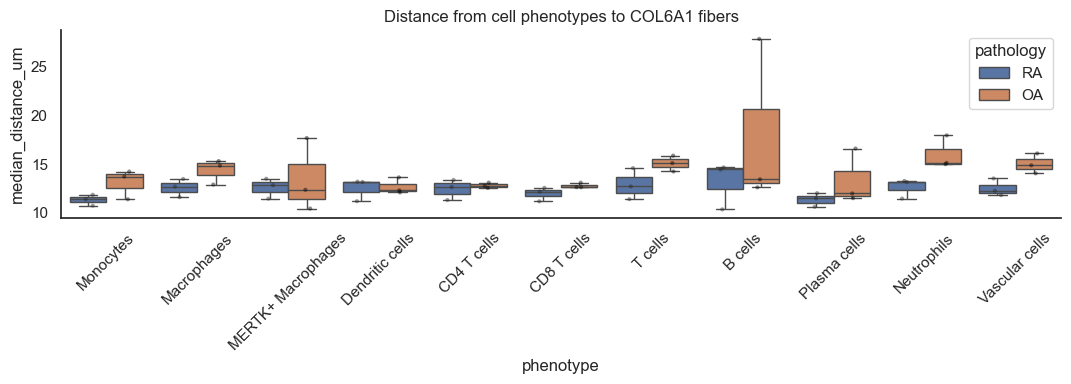

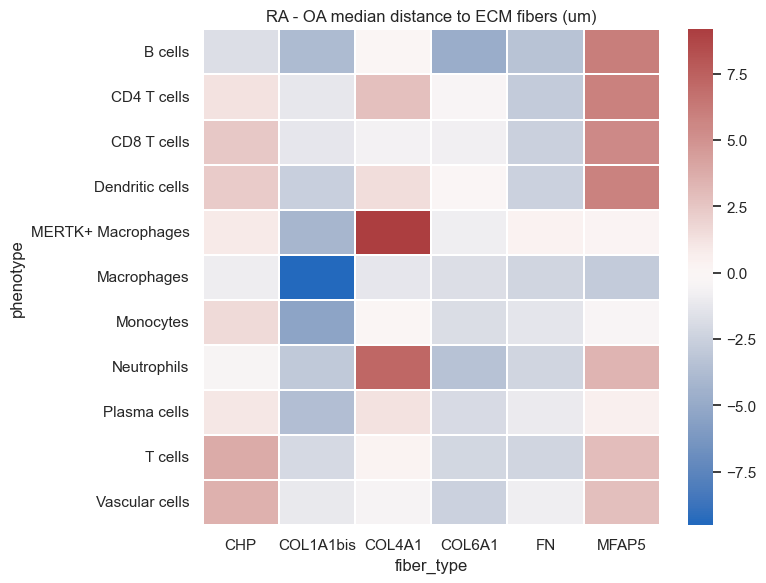

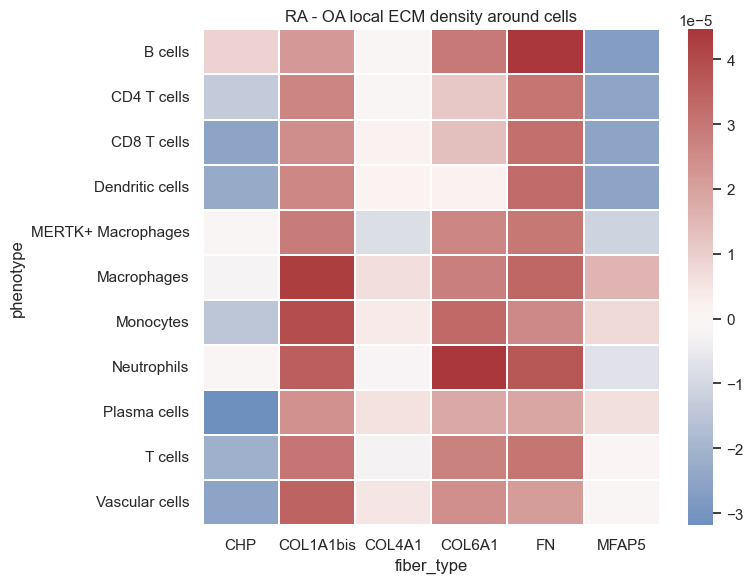

<Axes: title={'center': 'RA - OA local ECM density around cells'}, xlabel='fiber_type', ylabel='phenotype'>

In [8]:
if "COL6A1" in PAPER_FIBER_TYPES:
    col6_dist = proximity_summary[proximity_summary[FIBER_TYPE_KEY].eq("COL6A1")]
    plot_ra_oa_box(
        col6_dist,
        x=PHENOTYPE_KEY,
        y="median_distance_um",
        order=PAPER_CELL_TYPES,
        title="Distance from cell phenotypes to COL6A1 fibers",
        filename="01_col6_distance_by_phenotype_pathology.png",
        figsize=(11, 4),
    )

plot_heatmap(
    ra_oa_distance,
    row=PHENOTYPE_KEY,
    col=FIBER_TYPE_KEY,
    value="RA_minus_OA",
    title="RA - OA median distance to ECM fibers (um)",
    filename="01_ra_minus_oa_distance_heatmap.png",
    figsize=(8, 6),
)

plot_heatmap(
    ra_oa_density,
    row=PHENOTYPE_KEY,
    col=FIBER_TYPE_KEY,
    value="RA_minus_OA",
    title="RA - OA local ECM density around cells",
    filename="01_ra_minus_oa_density_heatmap.png",
    figsize=(8, 6),
)

## 2. COL6A1-rich versus COL6A1-poor neighborhoods

The paper defined COL6A1-rich and COL6A1-poor spatial niches from local COL6A1 fiber density, then tested immune-cell localization. We use two complementary views:

1. nearest-COL6A1 assignment, which is simple and comparable to the previous notebook;
2. explicit tissue-partitioned COL6A1-rich/poor regions, which let us estimate region area and cell density per square millimeter.

Important update: COL6A1-poor is now defined as the tissue area outside COL6A1-rich domains. The earlier approach built a concave hull around low-density COL6A1 fibers, which can wrap around most of the tissue because low-density fibers are widely distributed.


In [9]:
def add_local_fiber_density(fiber_subset, k=8, x_key="X_centroid", y_key="Y_centroid"):
    fiber_subset = fiber_subset.copy()
    coords = fiber_subset[[x_key, y_key]].to_numpy(dtype=float)
    valid = np.isfinite(coords).all(axis=1)
    fiber_subset["local_fiber_density"] = np.nan

    if valid.sum() < 3:
        return fiber_subset

    coords_valid = coords[valid]
    k_eff = min(k + 1, len(coords_valid))
    nn = NearestNeighbors(n_neighbors=k_eff)
    nn.fit(coords_valid)
    distances, _ = nn.kneighbors(coords_valid)
    kth_distance = distances[:, -1]
    density = k / (np.pi * np.maximum(kth_distance, 1e-9) ** 2)
    fiber_subset.loc[fiber_subset.index[valid], "local_fiber_density"] = density
    return fiber_subset


col6_zone_fibers = []
if "COL6A1" in PAPER_FIBER_TYPES:
    for img in SAMPLE_IDS:
        col6 = fiber_df[fiber_df[IMAGE_KEY].eq(img) & fiber_df[FIBER_TYPE_KEY].eq("COL6A1")].copy()
        if col6.empty:
            continue
        col6 = add_local_fiber_density(col6, k=8)
        cutoff = col6["local_fiber_density"].median()
        col6["COL6A1_zone"] = np.where(col6["local_fiber_density"] >= cutoff, "COL6A1-rich", "COL6A1-poor")
        col6_zone_fibers.append(col6)

col6_zone_fibers = pd.concat(col6_zone_fibers) if col6_zone_fibers else pd.DataFrame()
col6_zone_fibers.to_pickle(ANALYSIS_DIR / "02_col6_fibers_with_density_zones.pkl")
display(col6_zone_fibers[[IMAGE_KEY, GROUP_KEY, FIBER_TYPE_KEY, "local_fiber_density", "COL6A1_zone"]].head())

,imageid,pathology,fiber_type,local_fiber_density,COL6A1_zone
fiber_id,,,,,
JRP112__COL6A1__fov0__1__10125,JRP112,RA,COL6A1,0.000062,COL6A1-poor
JRP112__COL6A1__fov0__3__10126,JRP112,RA,COL6A1,0.000032,COL6A1-poor
JRP112__COL6A1__fov0__4__10127,JRP112,RA,COL6A1,0.000045,COL6A1-poor
JRP112__COL6A1__fov0__5__10128,JRP112,RA,COL6A1,0.000041,COL6A1-poor
JRP112__COL6A1__fov0__6__10129,JRP112,RA,COL6A1,0.000055,COL6A1-poor


In [10]:
col6_cell_zones = []
if not col6_zone_fibers.empty:
    col6_links = links_df[links_df["fiber_id"].isin(col6_zone_fibers.index)].copy()
    nearest_col6 = (
        col6_links
        .sort_values("distance")
        .groupby("cell_id", observed=True)
        .first()
        .reset_index()
    )
    nearest_col6 = nearest_col6.merge(
        col6_zone_fibers[["COL6A1_zone", "local_fiber_density"]],
        left_on="fiber_id",
        right_index=True,
        how="left",
    )

    # `nearest_col6` already has the link-table imageid. Merge only cell-level
    # disease/phenotype metadata to avoid imageid_x/imageid_y suffixes.
    nearest_col6 = nearest_col6.merge(
        adata.obs[[GROUP_KEY, PHENOTYPE_KEY]],
        left_on="cell_id",
        right_index=True,
        how="left",
    )

    # Defensive cleanup for notebooks where this cell was previously run with
    # imageid-suffixed columns.
    if IMAGE_KEY not in nearest_col6.columns:
        for candidate in [f"{IMAGE_KEY}_x", f"{IMAGE_KEY}_link", f"{IMAGE_KEY}_y"]:
            if candidate in nearest_col6.columns:
                nearest_col6[IMAGE_KEY] = nearest_col6[candidate]
                break

    nearest_col6["distance_um"] = nearest_col6["distance"] * PIXEL_SIZE_UM
    col6_cell_zones = nearest_col6

col6_cell_zones = pd.DataFrame(col6_cell_zones)
col6_cell_zones.to_csv(ANALYSIS_DIR / "02_cells_assigned_to_nearest_col6_zone.csv", index=False)
display(col6_cell_zones.head())


,cell_id,imageid,fiber_id,distance,COL6A1_zone,local_fiber_density,pathology,phenotype,distance_um
0,JRP112_1,JRP112,JRP112__COL6A1__fov0__5__10128,137.233246,COL6A1-poor,0.000041,RA,Non-immune cells,44.600805
1,JRP112_10,JRP112,JRP112__COL6A1__fov0__6__10129,46.575374,COL6A1-poor,0.000055,RA,Other Immune cells,15.136996
2,JRP112_100,JRP112,JRP112__COL6A1__fov0__32__10152,44.608581,COL6A1-poor,0.000052,RA,Monocytes,14.497789
3,JRP112_1000,JRP112,JRP112__COL6A1__fov0__301__10400,17.079116,COL6A1-rich,0.000170,RA,CD8 T cells,5.550713
4,JRP112_10000,JRP112,JRP112__COL6A1__fov0__1809__11817,21.161423,COL6A1-poor,0.000126,RA,CD4 T cells,6.877462


,imageid,pathology,phenotype,COL6A1_zone,n_cells,fraction
0,JRP112,RA,B cells,COL6A1-poor,219,0.509302
1,JRP112,RA,B cells,COL6A1-rich,211,0.490698
2,JRP112,RA,CD4 T cells,COL6A1-poor,6955,0.590107
3,JRP112,RA,CD4 T cells,COL6A1-rich,4831,0.409893
4,JRP112,RA,CD8 T cells,COL6A1-poor,1643,0.568709


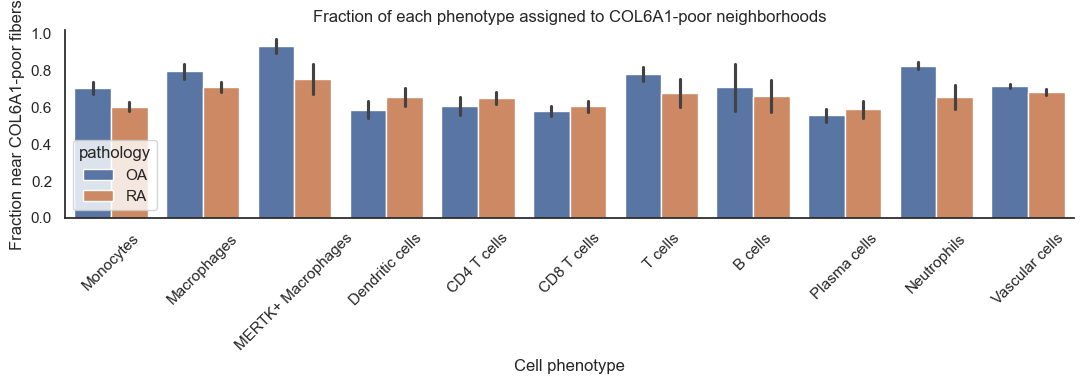

In [11]:
if not col6_cell_zones.empty:
    zone_counts = (
        col6_cell_zones[col6_cell_zones[PHENOTYPE_KEY].isin(PAPER_CELL_TYPES)]
        .groupby([IMAGE_KEY, GROUP_KEY, PHENOTYPE_KEY, "COL6A1_zone"], observed=True)
        .size()
        .reset_index(name="n_cells")
    )
    zone_totals = zone_counts.groupby([IMAGE_KEY, GROUP_KEY, PHENOTYPE_KEY], observed=True)["n_cells"].transform("sum")
    zone_counts["fraction"] = zone_counts["n_cells"] / zone_totals
    zone_counts.to_csv(ANALYSIS_DIR / "02_col6_zone_cell_frequencies.csv", index=False)
    display(zone_counts.head())

    fig, ax = plt.subplots(figsize=(11, 4))
    sns.barplot(
        data=zone_counts[zone_counts["COL6A1_zone"].eq("COL6A1-poor")],
        x=PHENOTYPE_KEY,
        y="fraction",
        hue=GROUP_KEY,
        order=PAPER_CELL_TYPES,
        errorbar="se",
        ax=ax,
    )
    ax.set_title("Fraction of each phenotype assigned to COL6A1-poor neighborhoods")
    ax.set_xlabel("Cell phenotype")
    ax.set_ylabel("Fraction near COL6A1-poor fibers")
    ax.tick_params(axis="x", rotation=45)
    sns.despine(ax=ax)
    savefig(fig, "02_col6_poor_fraction_by_phenotype.png")
    plt.show()

### 2b. Area-normalized COL6A1-rich versus COL6A1-poor cell density

Here we convert COL6A1-rich and COL6A1-poor fiber neighborhoods into approximate spatial regions. Because the current fiber tables contain centroids rather than full fiber masks, the region area is an approximation. The goal is still useful: compare cell density per unit area rather than only composition among linked cells.

Tuning parameters:

- `COL6_REGION_EPS_UM`: how close same-zone COL6A1 fibers must be to form a region component;
- `COL6_REGION_EXPAND_UM`: how far to expand each component boundary, similar to the paper's expanded boundary logic;
- `COL6_REGION_MIN_CLUSTER_SIZE`: filters tiny components that are hard to interpret biologically;
- `TISSUE_COMPONENT_EPS_UM`: how close cells must be to belong to the same tissue piece;
- `TISSUE_CONCAVITY` and `TISSUE_BUFFER_UM`: how tightly the tissue-piece boundary follows the cell cloud.

Important QC point: COL6A1-poor regions are now clipped to connected tissue pieces first. If the poor region still appears outside tissue, reduce `TISSUE_COMPONENT_EPS_UM`, reduce `TISSUE_BUFFER_UM`, or lower `TISSUE_CONCAVITY` for a tighter tissue boundary.

In [ ]:
COL6_RICH_QUANTILE = 0.50  # 0.50 mirrors the paper's median split; 0.75 gives stricter rich cores.
COL6_REGION_EPS_UM = 75
COL6_REGION_EXPAND_UM = 50
COL6_REGION_MIN_SAMPLES = 5
COL6_REGION_MIN_CLUSTER_SIZE = 20
COL6_REGION_CONCAVITY = 0.25
TISSUE_CONCAVITY = 0.22
TISSUE_BUFFER_UM = 10
TISSUE_COMPONENT_EPS_UM = 80
TISSUE_COMPONENT_MIN_SAMPLES = 20
TISSUE_COMPONENT_MIN_SIZE = 200

# Recompute rich/poor labels here so the cutoff used for regions is explicit.
if not col6_zone_fibers.empty:
    relabeled = []
    for img, sub in col6_zone_fibers.groupby(IMAGE_KEY, observed=True):
        sub = sub.copy()
        cutoff = sub["local_fiber_density"].quantile(COL6_RICH_QUANTILE)
        sub["COL6A1_zone"] = np.where(
            sub["local_fiber_density"] >= cutoff,
            "COL6A1-rich",
            "COL6A1-poor",
        )
        sub["COL6A1_density_cutoff"] = cutoff
        relabeled.append(sub)
    col6_zone_fibers = pd.concat(relabeled)

# Approximate tissue as connected pieces from the cell cloud, then define poor
# regions as tissue not occupied by COL6-rich domains. This avoids filling
# empty/off-tissue space between separate tissue fragments.
tissue_regions = build_tissue_regions_from_cells(
    adata.obs,
    max_points=30000,
    concavity=TISSUE_CONCAVITY,
    tissue_buffer_px=TISSUE_BUFFER_UM / PIXEL_SIZE_UM,
    tissue_eps_px=TISSUE_COMPONENT_EPS_UM / PIXEL_SIZE_UM,
    min_samples=TISSUE_COMPONENT_MIN_SAMPLES,
    min_component_size=TISSUE_COMPONENT_MIN_SIZE,
)

col6_region_components, col6_zone_regions = build_col6_rich_poor_regions_from_tissue(
    col6_zone_fibers,
    tissue_regions,
    rich_label="COL6A1-rich",
    poor_label="COL6A1-poor",
    region_eps_px=COL6_REGION_EPS_UM / PIXEL_SIZE_UM,
    region_expand_px=COL6_REGION_EXPAND_UM / PIXEL_SIZE_UM,
    min_samples=COL6_REGION_MIN_SAMPLES,
    min_cluster_size=COL6_REGION_MIN_CLUSTER_SIZE,
    concavity=COL6_REGION_CONCAVITY,
)

col6_zone_fibers = annotate_points_with_regions(
    col6_zone_fibers,
    col6_zone_regions,
    region_key="COL6A1_zone",
    out_col="COL6A1_region",
)

tissue_regions.to_pickle(ANALYSIS_DIR / "02_tissue_regions_from_cells.pkl")
col6_region_components.to_pickle(ANALYSIS_DIR / "02_col6_rich_region_components.pkl")
col6_zone_regions.to_pickle(ANALYSIS_DIR / "02_col6_zone_union_regions.pkl")
col6_zone_fibers.to_pickle(ANALYSIS_DIR / "02_col6_fibers_with_density_zones.pkl")

col6_area_summary = (
    col6_zone_regions
    .groupby([IMAGE_KEY, GROUP_KEY, "COL6A1_zone"], observed=True)["area_mm2"]
    .sum()
    .reset_index()
)
col6_area_summary["sample_area_mm2"] = col6_area_summary.groupby(IMAGE_KEY, observed=True)["area_mm2"].transform("sum")
col6_area_summary["area_fraction"] = col6_area_summary["area_mm2"] / col6_area_summary["sample_area_mm2"]
col6_area_summary.to_csv(ANALYSIS_DIR / "02_col6_zone_area_summary.csv", index=False)

display(col6_zone_regions[[IMAGE_KEY, GROUP_KEY, "COL6A1_zone", "region_class", "area_mm2", "n_fibers"]].head())
display(col6_area_summary)


In [ ]:
col6_region_cell_density = summarize_cells_in_regions(
    adata.obs,
    col6_zone_regions,
    region_key="COL6A1_zone",
    phenotypes=PAPER_CELL_TYPES,
)
col6_region_cell_density.to_csv(ANALYSIS_DIR / "02_col6_region_cell_density_per_area.csv", index=False)
display(col6_region_cell_density.head())

fig, ax = plt.subplots(figsize=(11, 4))
sns.barplot(
    data=col6_region_cell_density[col6_region_cell_density["COL6A1_zone"].isin(["COL6A1-rich", "COL6A1-poor"])],
    x=PHENOTYPE_KEY,
    y="cell_density_per_mm2",
    hue="COL6A1_zone",
    order=PAPER_CELL_TYPES,
    errorbar="se",
    ax=ax,
)
ax.set_title("Cell density in COL6A1-rich versus COL6A1-poor regions")
ax.set_xlabel("Cell phenotype")
ax.set_ylabel("Cells per mm2")
ax.tick_params(axis="x", rotation=45)
sns.despine(ax=ax)
savefig(fig, "02_col6_region_cell_density_by_phenotype.png")
plt.show()

In [ ]:
if col6_region_cell_density.empty:
    col6_region_density_ra_oa = pd.DataFrame()
else:
    col6_region_density_ra_oa = summarize_ra_oa(
        col6_region_cell_density,
        value_col="cell_density_per_mm2",
        group_cols=[PHENOTYPE_KEY, "COL6A1_zone"],
    )

col6_region_density_ra_oa.to_csv(ANALYSIS_DIR / "02_ra_oa_col6_region_cell_density_comparison.csv", index=False)
display(col6_region_density_ra_oa.head(12))

if not col6_region_density_ra_oa.empty:
    plot_heatmap(
        col6_region_density_ra_oa,
        row=PHENOTYPE_KEY,
        col="COL6A1_zone",
        value="RA_minus_OA",
        title="RA - OA cell density in COL6A1-rich/poor regions",
        filename="02_ra_minus_oa_col6_region_density_heatmap.png",
        figsize=(5, 6),
    )


In [ ]:
# Spatial QC overlays. Pick one RA and one OA sample by default.
example_images = []
for group in ["RA", "OA"]:
    sample = adata.obs.loc[adata.obs[GROUP_KEY].eq(group), IMAGE_KEY].dropna().unique()
    if len(sample) > 0:
        example_images.append(sample[0])

for image_id in example_images:
    plot_col6_zone_overlay(
        image_id,
        region_df=col6_zone_regions,
        col6_fibers=col6_zone_fibers,
        cell_types=[p for p in ["Monocytes", "CD4 T cells", "B cells", "MERTK+ Macrophages"] if p in PAPER_CELL_TYPES],
        max_background=50000,
    )
    plot_col6_region_scatter(
        image_id,
        region_df=col6_zone_regions,
        col6_fibers=col6_zone_fibers,
        region_col="COL6A1_region",
        max_background=50000,
    )

## 3. Cross Ripley's K: point-scale cell-ECM association

Cross Ripley's K asks whether selected cell phenotypes and ECM fiber centroids are associated or separated across radii.

This is complementary to the paper's COL6-dark analysis, but it is not the same statistical question. The paper's immune-exclusion result is region-based, while Ripley's K is point-process based. If Ripley curves do not perfectly match the COL6-rich/poor region analysis, prioritize the area-normalized region-density results for validating the paper's dark-zone biology.

Paper-guided pairs focus on:

- lymphocytes versus COL6A1, to test immune exclusion;
- monocytes/macrophages versus COL6A1 and CHP, to test matrix turnover niches;
- vascular cells versus COL4A1, as a vascular-positive sanity check.

In [12]:
RIPLEY_PAIRS = [
    ("Monocytes", "COL6A1"),
    ("Macrophages", "COL6A1"),
    ("MERTK+ Macrophages", "COL6A1"),
    ("Dendritic cells", "COL6A1"),
    ("CD4 T cells", "COL6A1"),
    ("CD8 T cells", "COL6A1"),
    ("B cells", "COL6A1"),
    ("Monocytes", "CHP"),
    ("Macrophages", "CHP"),
    ("Vascular cells", "COL4A1"),
]
RIPLEY_PAIRS = [(p, f) for p, f in RIPLEY_PAIRS if p in EXISTING_PHENOTYPES and f in FIBER_TYPES]
print(RIPLEY_PAIRS)

[('Monocytes', 'COL6A1'), ('Macrophages', 'COL6A1'), ('MERTK+ Macrophages', 'COL6A1'), ('Dendritic cells', 'COL6A1'), ('CD4 T cells', 'COL6A1'), ('CD8 T cells', 'COL6A1'), ('B cells', 'COL6A1'), ('Monocytes', 'CHP'), ('Macrophages', 'CHP'), ('Vascular cells', 'COL4A1')]


In [13]:
cross_ripley_rows = []
failed_ripley = []

for img in SAMPLE_IDS:
    adata_img = subset_obs_adata(adata, adata.obs[IMAGE_KEY].eq(img))
    fibers_img = fiber_df[fiber_df[IMAGE_KEY].eq(img)].copy()
    links_img = links_df[links_df[IMAGE_KEY].eq(img)].copy()
    pathology = adata_img.obs[GROUP_KEY].dropna().mode().iloc[0]

    for phenotype, fiber_type in RIPLEY_PAIRS:
        try:
            curve = ecm_cross_ripleys_k(
                adata_img,
                fibers_img,
                links_img,
                radii=RIPLEY_RADII_PX,
                fiber_type_key=FIBER_TYPE_KEY,
                fiber_type=fiber_type,
                phenotype_key=PHENOTYPE_KEY,
                phenotype=phenotype,
                check_radius=False,
            )
        except Exception as exc:
            failed_ripley.append({IMAGE_KEY: img, PHENOTYPE_KEY: phenotype, FIBER_TYPE_KEY: fiber_type, "error": str(exc)})
            continue

        if curve.empty:
            continue

        curve = curve.copy()
        curve["radius_um"] = curve["radius"] * PIXEL_SIZE_UM
        curve[IMAGE_KEY] = img
        curve[GROUP_KEY] = pathology
        curve[PHENOTYPE_KEY] = phenotype
        curve[FIBER_TYPE_KEY] = fiber_type
        cross_ripley_rows.append(curve)

cross_ripley_curves = pd.concat(cross_ripley_rows, ignore_index=True) if cross_ripley_rows else pd.DataFrame()
failed_ripley = pd.DataFrame(failed_ripley)
cross_ripley_curves = add_pair_label(cross_ripley_curves) if not cross_ripley_curves.empty else cross_ripley_curves

cross_ripley_curves.to_csv(ANALYSIS_DIR / "03_cross_ripley_paper_guided_curves.csv", index=False)
failed_ripley.to_csv(ANALYSIS_DIR / "03_cross_ripley_failures.csv", index=False)

display(cross_ripley_curves.head())
print("Failed combinations:", len(failed_ripley))

,radius,K,L,L_minus_r,radius_um,imageid,pathology,phenotype,fiber_type,cell_fiber_pair
0,30.769231,9555.286493,55.150178,24.380947,10.0,JRP112,RA,Monocytes,COL6A1,Monocytes vs COL6A1
1,61.538462,37637.737392,109.455306,47.916844,20.0,JRP112,RA,Monocytes,COL6A1,Monocytes vs COL6A1
2,92.307692,82047.744666,161.606337,69.298645,30.0,JRP112,RA,Monocytes,COL6A1,Monocytes vs COL6A1
3,123.076923,142948.242245,213.311600,90.234677,40.0,JRP112,RA,Monocytes,COL6A1,Monocytes vs COL6A1
4,153.846154,221461.371858,265.505827,111.659673,50.0,JRP112,RA,Monocytes,COL6A1,Monocytes vs COL6A1


Failed combinations: 0


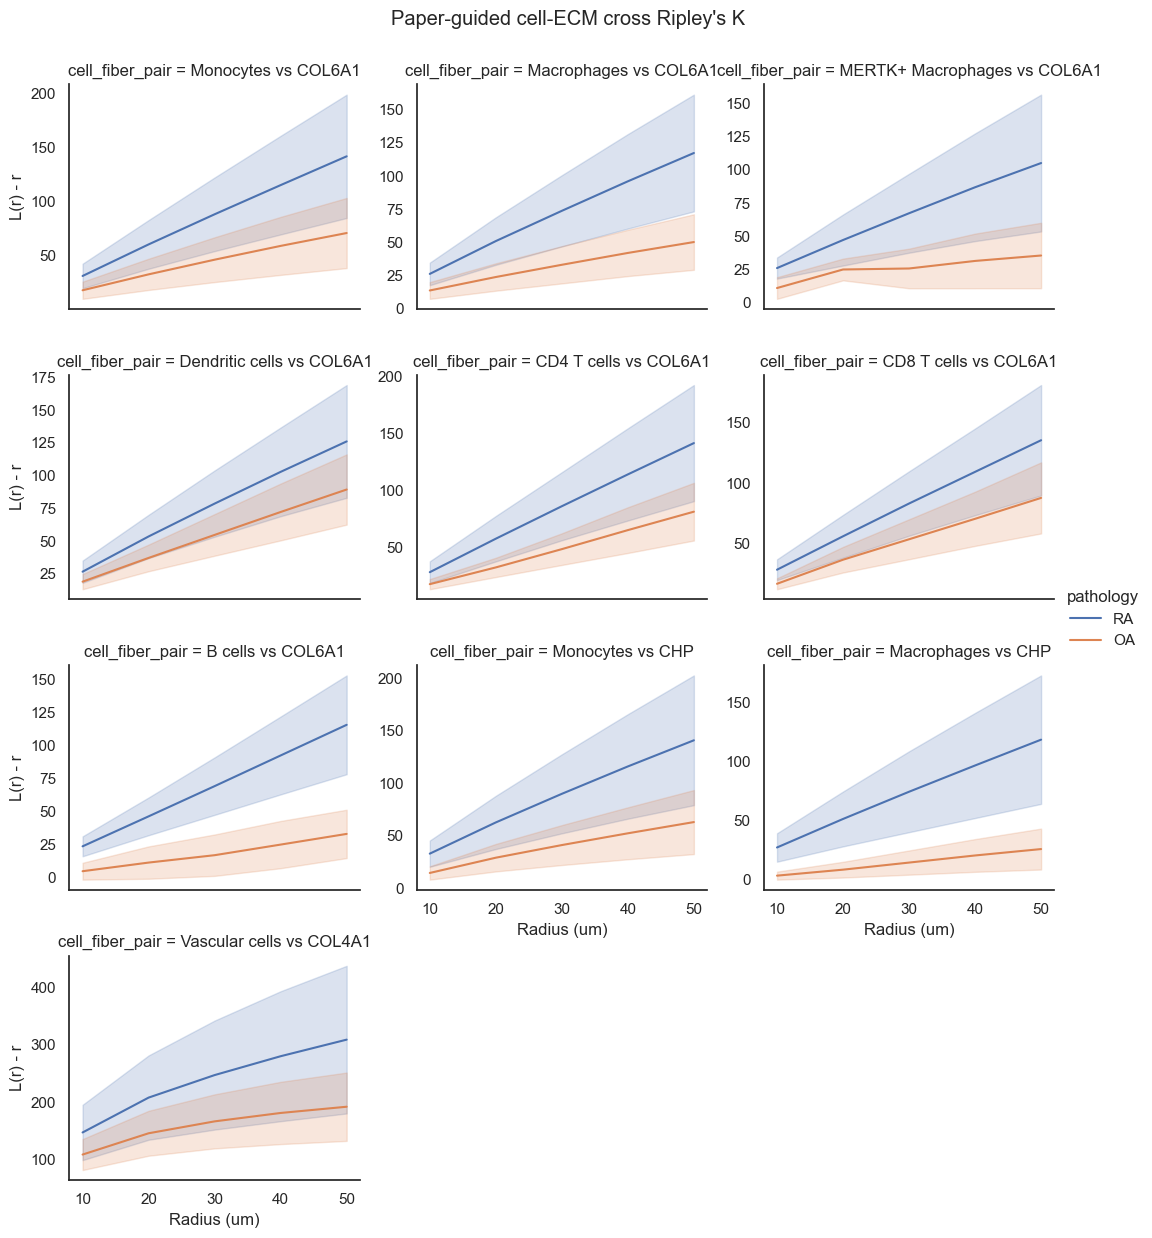

In [14]:
if not cross_ripley_curves.empty:
    g = sns.relplot(
        data=cross_ripley_curves,
        x="radius_um",
        y="L_minus_r",
        hue=GROUP_KEY,
        col="cell_fiber_pair",
        col_wrap=3,
        kind="line",
        estimator="mean",
        errorbar="se",
        facet_kws={"sharey": False},
        height=3,
        aspect=1.2,
    )
    g.set_axis_labels("Radius (um)", "L(r) - r")
    g.fig.suptitle("Paper-guided cell-ECM cross Ripley's K", y=1.03)
    g.fig.savefig(FIGURES_DIR / "03_cross_ripley_curves_by_pair.png", dpi=300, bbox_inches="tight")
    plt.show()

In [15]:
RUN_RIPLEY_PERMUTATIONS = False
RIPLEY_N_SIM = 199
RIPLEY_PERMUTATION_PAIRS = [
    ("Monocytes", "COL6A1"),
    ("CD4 T cells", "COL6A1"),
    ("Macrophages", "CHP"),
]
RIPLEY_PERMUTATION_PAIRS = [(p, f) for p, f in RIPLEY_PERMUTATION_PAIRS if p in EXISTING_PHENOTYPES and f in FIBER_TYPES]

ripley_envelope_rows = []

if RUN_RIPLEY_PERMUTATIONS:
    for img in SAMPLE_IDS:
        adata_img = subset_obs_adata(adata, adata.obs[IMAGE_KEY].eq(img))
        fibers_img = fiber_df[fiber_df[IMAGE_KEY].eq(img)].copy()
        links_img = links_df[links_df[IMAGE_KEY].eq(img)].copy()
        pathology = adata_img.obs[GROUP_KEY].dropna().mode().iloc[0]

        for phenotype, fiber_type in RIPLEY_PERMUTATION_PAIRS:
            env = cross_ripleys_k_permutation_envelope(
                adata_img,
                fibers_img,
                links_img,
                radii=RIPLEY_RADII_PX,
                fiber_type_key=FIBER_TYPE_KEY,
                fiber_type=fiber_type,
                phenotype_key=PHENOTYPE_KEY,
                phenotype=phenotype,
                permute="cells",
                n_sim=RIPLEY_N_SIM,
                image_key=IMAGE_KEY,
                fiber_image_key=IMAGE_KEY,
                random_state=0,
                check_radius=False,
            )
            env = env.copy()
            env["radius_um"] = env["radius"] * PIXEL_SIZE_UM
            env[IMAGE_KEY] = img
            env[GROUP_KEY] = pathology
            env[PHENOTYPE_KEY] = phenotype
            env[FIBER_TYPE_KEY] = fiber_type
            ripley_envelope_rows.append(env)

ripley_envelopes = pd.concat(ripley_envelope_rows, ignore_index=True) if ripley_envelope_rows else pd.DataFrame()
ripley_envelopes = add_pair_label(ripley_envelopes) if not ripley_envelopes.empty else ripley_envelopes
ripley_envelopes.to_csv(ANALYSIS_DIR / "03_cross_ripley_permutation_envelopes.csv", index=False)
display(ripley_envelopes.head())

""


## 4. Perivascular COL6A1/COL4A1 niche

The paper highlights perivascular collagen VI biology. Here we operationalize that with the data available in this dataset:

1. identify COL6A1 fibers near COL4A1-rich vascular fiber neighborhoods;
2. compare COL6A1 morphology in perivascular versus non-perivascular contexts;
3. map MERTK+ macrophages, T cells, and vascular cells onto COL6A1 fibers;
4. test whether COL4A1-near COL6A1 fibers are more coupled to those cell niches.

In [ ]:
def annotate_col6_near_col4(
    fiber_df,
    col4_radius_px,
    rich_quantile=0.5,
):
    rows = []
    for img in SAMPLE_IDS:
        col6 = fiber_df[fiber_df[IMAGE_KEY].eq(img) & fiber_df[FIBER_TYPE_KEY].eq("COL6A1")].copy()
        col4 = fiber_df[fiber_df[IMAGE_KEY].eq(img) & fiber_df[FIBER_TYPE_KEY].eq("COL4A1")].copy()
        if col6.empty or col4.empty:
            continue

        col4 = add_local_fiber_density(col4, k=8)
        cutoff = col4["local_fiber_density"].quantile(rich_quantile)
        col4_rich = col4[col4["local_fiber_density"] >= cutoff].copy()

        col6_coords = col6[["X_centroid", "Y_centroid"]].to_numpy(dtype=float)
        all_coords = col4[["X_centroid", "Y_centroid"]].to_numpy(dtype=float)
        rich_coords = col4_rich[["X_centroid", "Y_centroid"]].to_numpy(dtype=float)

        nn_all = NearestNeighbors(n_neighbors=1).fit(all_coords)
        dist_all, _ = nn_all.kneighbors(col6_coords)
        col6["dist_to_COL4A1_um"] = dist_all[:, 0] * PIXEL_SIZE_UM
        col6["near_COL4A1_50um"] = col6["dist_to_COL4A1_um"] <= 50

        if len(rich_coords) > 0:
            nn_rich = NearestNeighbors(n_neighbors=1).fit(rich_coords)
            dist_rich, _ = nn_rich.kneighbors(col6_coords)
            col6["dist_to_COL4A1_rich_um"] = dist_rich[:, 0] * PIXEL_SIZE_UM
            col6["near_COL4A1_rich_50um"] = col6["dist_to_COL4A1_rich_um"] <= 50

            radius_neighbors = NearestNeighbors(radius=col4_radius_px).fit(rich_coords)
            indices = radius_neighbors.radius_neighbors(col6_coords, return_distance=False)
            counts = np.array([len(idx) for idx in indices], dtype=float)
            col6["COL4A1_rich_density_near_COL6A1"] = counts / (np.pi * col4_radius_px ** 2)
        else:
            col6["dist_to_COL4A1_rich_um"] = np.nan
            col6["near_COL4A1_rich_50um"] = False
            col6["COL4A1_rich_density_near_COL6A1"] = np.nan

        rows.append(col6)

    return pd.concat(rows) if rows else pd.DataFrame()


perivascular_col6 = annotate_col6_near_col4(
    fiber_df,
    col4_radius_px=50 / PIXEL_SIZE_UM,
    rich_quantile=0.5,
)
perivascular_col6.to_pickle(ANALYSIS_DIR / "04_perivascular_col6_fibers.pkl")
display(perivascular_col6[[IMAGE_KEY, GROUP_KEY, "dist_to_COL4A1_rich_um", "near_COL4A1_rich_50um", "COL4A1_rich_density_near_COL6A1"]].head())

In [ ]:
perivascular_morphology = (
    perivascular_col6
    .groupby([IMAGE_KEY, GROUP_KEY, "near_COL4A1_rich_50um"], observed=True)[FIBER_FEATURES]
    .mean()
    .reset_index()
)
perivascular_morphology.to_csv(ANALYSIS_DIR / "04_perivascular_col6_morphology.csv", index=False)
display(perivascular_morphology.head())

if "alignment_score" in FIBER_FEATURES:
    plot_ra_oa_box(
        perivascular_col6.rename(columns={"near_COL4A1_rich_50um": "COL4A1-rich proximity"}),
        x="COL4A1-rich proximity",
        y="alignment_score",
        title="COL6A1 alignment near COL4A1-rich vascular regions",
        filename="04_col6_alignment_near_col4_rich.png",
        figsize=(5.5, 4),
        rotate=0,
    )

In [ ]:
PERIVASCULAR_CELL_TYPES = [p for p in ["MERTK+ Macrophages", "T cells", "CD4 T cells", "CD8 T cells", "Vascular cells"] if p in EXISTING_PHENOTYPES]
perivascular_signal_rows = []

for img in SAMPLE_IDS:
    obs_img = adata.obs.loc[adata.obs[IMAGE_KEY].eq(img)].copy()
    adata_img = ObsOnlyAnnData(obs_img)
    col6_img = perivascular_col6[perivascular_col6[IMAGE_KEY].eq(img)].copy()
    links_img = links_df[links_df[IMAGE_KEY].eq(img)].copy()
    pathology = obs_img[GROUP_KEY].dropna().mode().iloc[0]

    for phenotype in PERIVASCULAR_CELL_TYPES:
        mapped = map_cells_to_fibers_kernel(
            adata_img,
            col6_img,
            links_img,
            phenotype_key=PHENOTYPE_KEY,
            phenotype=phenotype,
            bandwidth=CELL_FIBER_BANDWIDTH_PX,
        )
        signal_col = f"{phenotype}_kernel_density"
        summary = (
            mapped
            .groupby("near_COL4A1_rich_50um", observed=True)[signal_col]
            .agg(n_fibers="size", mean_signal="mean", median_signal="median")
            .reset_index()
        )
        summary[IMAGE_KEY] = img
        summary[GROUP_KEY] = pathology
        summary[PHENOTYPE_KEY] = phenotype
        perivascular_signal_rows.append(summary)

perivascular_cell_signal = pd.concat(perivascular_signal_rows, ignore_index=True) if perivascular_signal_rows else pd.DataFrame()
perivascular_cell_signal.to_csv(ANALYSIS_DIR / "04_perivascular_col6_cell_signals.csv", index=False)
display(perivascular_cell_signal.head())

if not perivascular_cell_signal.empty:
    g = sns.catplot(
        data=perivascular_cell_signal,
        x=PHENOTYPE_KEY,
        y="mean_signal",
        hue="near_COL4A1_rich_50um",
        col=GROUP_KEY,
        kind="bar",
        errorbar="se",
        height=4,
        aspect=1.35,
        sharey=False,
    )
    g.set_axis_labels("Cell phenotype", "Kernel density around COL6A1 fibers")
    g.set_titles("{col_name}")
    for ax in g.axes.flat:
        ax.tick_params(axis="x", rotation=45)
    g.fig.suptitle("Cells around COL6A1 fibers near COL4A1-rich vascular regions", y=1.08)
    g.fig.savefig(FIGURES_DIR / "04_perivascular_col6_cell_signals.png", dpi=300, bbox_inches="tight")
    plt.show()

In [ ]:
perivascular_cross_moran_rows = []
for img in SAMPLE_IDS:
    obs_img = adata.obs.loc[adata.obs[IMAGE_KEY].eq(img)].copy()
    pathology = obs_img[GROUP_KEY].dropna().mode().iloc[0]
    col6_img = perivascular_col6[perivascular_col6[IMAGE_KEY].eq(img)].copy()
    links_img = links_df[links_df[IMAGE_KEY].eq(img)].copy()

    for phenotype in PERIVASCULAR_CELL_TYPES:
        feature_cell = f"is_{safe_label(phenotype)}"
        obs_tmp = obs_img.copy()
        obs_tmp[feature_cell] = obs_tmp[PHENOTYPE_KEY].eq(phenotype).astype(float)
        adata_img = ObsOnlyAnnData(obs_tmp)

        for fiber_feature in ["COL4A1_rich_density_near_COL6A1", "alignment_score", "area"]:
            if fiber_feature not in col6_img.columns:
                continue
            stat = cross_morans_i_ecm_cells(
                adata_img,
                col6_img,
                links_img,
                feature_fiber=fiber_feature,
                cell_feature=feature_cell,
                k=KNN_K,
            )
            perivascular_cross_moran_rows.append({
                IMAGE_KEY: img,
                GROUP_KEY: pathology,
                PHENOTYPE_KEY: phenotype,
                FIBER_TYPE_KEY: "COL6A1",
                "feature_fiber": fiber_feature,
                "cross_morans_i": stat,
            })

perivascular_cross_moran = pd.DataFrame(perivascular_cross_moran_rows)
perivascular_cross_moran.to_csv(ANALYSIS_DIR / "04_perivascular_cross_moran.csv", index=False)
display(perivascular_cross_moran.head())

perivascular_cross_moran_diff = summarize_ra_oa(
    perivascular_cross_moran,
    value_col="cross_morans_i",
    group_cols=[PHENOTYPE_KEY, "feature_fiber"],
)
perivascular_cross_moran_diff.to_csv(ANALYSIS_DIR / "04_ra_oa_perivascular_cross_moran_comparison.csv", index=False)
display(perivascular_cross_moran_diff.head(12))

## 5. ECM structural organization: fiber Moran's I

This block asks whether fiber morphology features are spatially clustered. It is useful for testing whether RA and OA differ in the organization of collagen and matrix-turnover structures.

Examples:

- spatial clustering of COL6A1 alignment or area;
- spatial organization of CHP-positive degradation-associated structures;
- RA versus OA differences in collagen organization.

In [16]:
moran_rows = []

for img in SAMPLE_IDS:
    fibers_img = fiber_df[fiber_df[IMAGE_KEY].eq(img)].copy()
    pathology = fibers_img[GROUP_KEY].dropna().mode().iloc[0]

    for fiber_type in PAPER_FIBER_TYPES:
        for feature in FIBER_FEATURES:
            try:
                stat = morans_i_fibers(
                    fibers_img,
                    feature=feature,
                    k=KNN_K,
                    fiber_type_key=FIBER_TYPE_KEY,
                    fiber_type=fiber_type,
                )
            except ValueError:
                stat = np.nan

            moran_rows.append({
                IMAGE_KEY: img,
                GROUP_KEY: pathology,
                FIBER_TYPE_KEY: fiber_type,
                "feature": feature,
                "morans_i": stat,
            })

fiber_moran_summary = pd.DataFrame(moran_rows)
fiber_moran_summary.to_csv(ANALYSIS_DIR / "04_fiber_morans_i_by_sample.csv", index=False)

display(fiber_moran_summary.head())

,imageid,pathology,fiber_type,feature,morans_i
0,JRP112,RA,COL6A1,alignment_score,0.440248
1,JRP112,RA,COL6A1,area,-0.004977
2,JRP112,RA,COL6A1,major_axis_length,0.003504
3,JRP112,RA,COL6A1,minor_axis_length,-0.008184
4,JRP112,RA,COL6A1,eccentricity,0.033336


,fiber_type,feature,n_RA,n_OA,mean_RA,mean_OA,RA_minus_OA,p_value_mannwhitney
10,COL4A1,alignment_score,3,3,0.465460,0.314091,0.151369,0.1
25,MFAP5,alignment_score,3,3,0.454126,0.351594,0.102532,0.1
0,CHP,alignment_score,3,3,0.416419,0.340941,0.075477,0.1
5,COL1A1bis,alignment_score,3,3,0.387881,0.328690,0.059192,0.4
20,FN,alignment_score,3,3,0.352042,0.300062,0.051980,0.2
15,COL6A1,alignment_score,3,3,0.377029,0.329818,0.047211,0.1
12,COL4A1,eccentricity,3,3,0.099019,0.057970,0.041049,0.4
14,COL4A1,minor_axis_length,3,3,0.073070,0.034573,0.038496,0.4
13,COL4A1,major_axis_length,3,3,0.053821,0.022323,0.031498,0.1
29,MFAP5,minor_axis_length,3,3,0.018423,-0.011124,0.029546,0.1


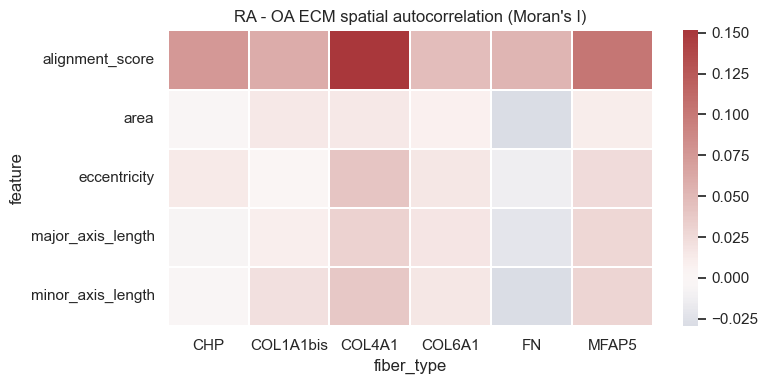

/var/folders/kg/btvhyzjs5fb7f_57bfqf24tr0000gn/T/ipykernel_28794/2338985669.py:13: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(data=plot_df, x=x, y=y, hue=hue, order=order, dodge=True, color="black", alpha=0.45, size=3, legend=False, ax=ax)


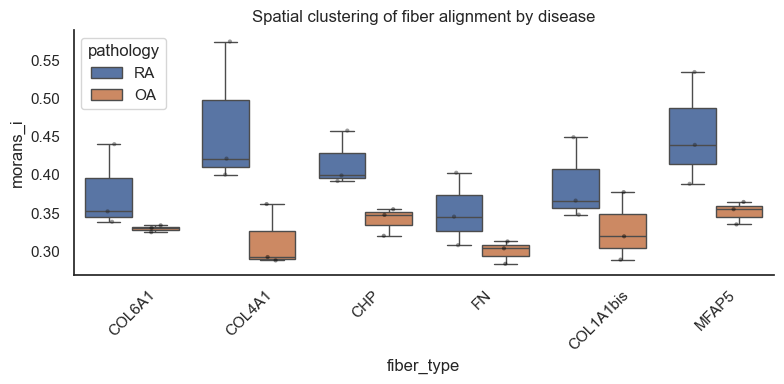

<Axes: title={'center': 'Spatial clustering of fiber alignment by disease'}, xlabel='fiber_type', ylabel='morans_i'>

In [17]:
ra_oa_fiber_moran = summarize_ra_oa(fiber_moran_summary, "morans_i", [FIBER_TYPE_KEY, "feature"])
ra_oa_fiber_moran.to_csv(ANALYSIS_DIR / "04_ra_oa_fiber_moran_comparison.csv", index=False)
display(ra_oa_fiber_moran.head(12))

plot_heatmap(
    ra_oa_fiber_moran,
    row="feature",
    col=FIBER_TYPE_KEY,
    value="RA_minus_OA",
    title="RA - OA ECM spatial autocorrelation (Moran's I)",
    filename="04_ra_minus_oa_fiber_moran_heatmap.png",
    figsize=(8, 4),
)

plot_ra_oa_box(
    fiber_moran_summary[fiber_moran_summary["feature"].eq("alignment_score")],
    x=FIBER_TYPE_KEY,
    y="morans_i",
    title="Spatial clustering of fiber alignment by disease",
    filename="04_alignment_morans_i_by_fiber_type.png",
    figsize=(8, 4),
)

### COL6A1-rich/poor region-specific ECM organization

The previous Moran's I block summarizes each whole sample. Here we ask the more paper-aligned question: are ECM features spatially organized differently inside COL6A1-rich versus COL6A1-poor regions, and does that differ between RA and OA?

In [ ]:
fiber_col6_regions = annotate_points_with_regions(
    fiber_df,
    col6_zone_regions,
    region_key="COL6A1_zone",
    out_col="COL6A1_region",
)
fiber_col6_regions.to_pickle(ANALYSIS_DIR / "04_fibers_annotated_by_col6_region.pkl")
display(fiber_col6_regions[[IMAGE_KEY, GROUP_KEY, FIBER_TYPE_KEY, "COL6A1_region"]].head())

In [ ]:
zone_moran_rows = []
for img in SAMPLE_IDS:
    fibers_img = fiber_col6_regions[fiber_col6_regions[IMAGE_KEY].eq(img)].copy()
    pathology = fibers_img[GROUP_KEY].dropna().mode().iloc[0]

    for zone in ["COL6A1-rich", "COL6A1-poor"]:
        fibers_zone = fibers_img[fibers_img["COL6A1_region"].eq(zone)].copy()
        if fibers_zone.empty:
            continue
        for fiber_type in PAPER_FIBER_TYPES:
            for feature in FIBER_FEATURES:
                try:
                    stat = morans_i_fibers(
                        fibers_zone,
                        feature=feature,
                        k=KNN_K,
                        fiber_type_key=FIBER_TYPE_KEY,
                        fiber_type=fiber_type,
                    )
                except ValueError:
                    stat = np.nan

                zone_moran_rows.append({
                    IMAGE_KEY: img,
                    GROUP_KEY: pathology,
                    "COL6A1_region": zone,
                    FIBER_TYPE_KEY: fiber_type,
                    "feature": feature,
                    "morans_i": stat,
                })

zone_fiber_moran_summary = pd.DataFrame(zone_moran_rows)
zone_fiber_moran_summary.to_csv(ANALYSIS_DIR / "04_col6_region_fiber_morans_i_by_sample.csv", index=False)
display(zone_fiber_moran_summary.head())

In [ ]:
if zone_fiber_moran_summary.empty:
    zone_fiber_moran_diff = pd.DataFrame()
else:
    zone_fiber_moran_diff = summarize_ra_oa(
        zone_fiber_moran_summary,
        value_col="morans_i",
        group_cols=["COL6A1_region", FIBER_TYPE_KEY, "feature"],
    )

zone_fiber_moran_diff.to_csv(ANALYSIS_DIR / "04_ra_oa_col6_region_fiber_moran_comparison.csv", index=False)
display(zone_fiber_moran_diff.head(12))

if not zone_fiber_moran_diff.empty:
    for zone in ["COL6A1-rich", "COL6A1-poor"]:
        plot_heatmap(
            zone_fiber_moran_diff[zone_fiber_moran_diff["COL6A1_region"].eq(zone)],
            row="feature",
            col=FIBER_TYPE_KEY,
            value="RA_minus_OA",
            title=f"RA - OA fiber Moran's I inside {zone} regions",
            filename=f"04_ra_minus_oa_fiber_moran_{safe_label(zone)}.png",
            figsize=(8, 4),
        )


## 6. Cross Moran's I: ECM structure coupled to cell niches

Cross Moran's I maps a cell signal onto fibers, then asks whether that signal is spatially coupled to a fiber feature.

Paper-guided examples:

- monocyte-rich neighborhoods coupled to COL6A1 or CHP features;
- MERTK+ macrophage and T-cell niches coupled to COL6A1 structure;
- vascular cell signal coupled to COL4A1 structure.

In [18]:
CROSS_MORAN_PAIRS = [
    ("Monocytes", "COL6A1"),
    ("Macrophages", "COL6A1"),
    ("MERTK+ Macrophages", "COL6A1"),
    ("CD4 T cells", "COL6A1"),
    ("CD8 T cells", "COL6A1"),
    ("B cells", "COL6A1"),
    ("Monocytes", "CHP"),
    ("Macrophages", "CHP"),
    ("Vascular cells", "COL4A1"),
]
CROSS_MORAN_PAIRS = [(p, f) for p, f in CROSS_MORAN_PAIRS if p in EXISTING_PHENOTYPES and f in FIBER_TYPES]
CROSS_MORAN_FEATURES = [f for f in ["alignment_score", "area", "major_axis_length", "eccentricity"] if f in FIBER_FEATURES]
print(CROSS_MORAN_PAIRS)
print(CROSS_MORAN_FEATURES)

[('Monocytes', 'COL6A1'), ('Macrophages', 'COL6A1'), ('MERTK+ Macrophages', 'COL6A1'), ('CD4 T cells', 'COL6A1'), ('CD8 T cells', 'COL6A1'), ('B cells', 'COL6A1'), ('Monocytes', 'CHP'), ('Macrophages', 'CHP'), ('Vascular cells', 'COL4A1')]
['alignment_score', 'area', 'major_axis_length', 'eccentricity']


In [19]:
cross_moran_rows = []

for img in SAMPLE_IDS:
    obs_img_base = adata.obs.loc[adata.obs[IMAGE_KEY].eq(img)].copy()
    pathology = obs_img_base[GROUP_KEY].dropna().mode().iloc[0]
    fibers_img = fiber_df[fiber_df[IMAGE_KEY].eq(img)].copy()
    links_img = links_df[links_df[IMAGE_KEY].eq(img)].copy()

    for phenotype, fiber_type in CROSS_MORAN_PAIRS:
        feature_cell = f"is_{safe_label(phenotype)}"
        obs_img = obs_img_base.copy()
        obs_img[feature_cell] = obs_img[PHENOTYPE_KEY].eq(phenotype).astype(float)
        adata_img = ObsOnlyAnnData(obs_img)
        fibers_ft = fibers_img[fibers_img[FIBER_TYPE_KEY].eq(fiber_type)].copy()

        if fibers_ft.empty:
            continue

        for feature_fiber in CROSS_MORAN_FEATURES:
            stat = cross_morans_i_ecm_cells(
                adata_img,
                fibers_ft,
                links_img,
                feature_fiber=feature_fiber,
                cell_feature=feature_cell,
                k=KNN_K,
            )
            cross_moran_rows.append({
                IMAGE_KEY: img,
                GROUP_KEY: pathology,
                PHENOTYPE_KEY: phenotype,
                FIBER_TYPE_KEY: fiber_type,
                "feature_fiber": feature_fiber,
                "cell_feature": feature_cell,
                "cross_morans_i": stat,
            })

cross_moran_summary = pd.DataFrame(cross_moran_rows)
cross_moran_summary = add_pair_label(cross_moran_summary) if not cross_moran_summary.empty else cross_moran_summary
cross_moran_summary.to_csv(ANALYSIS_DIR / "05_cross_morans_i_cell_ecm_by_sample.csv", index=False)
display(cross_moran_summary.head())

,imageid,pathology,phenotype,fiber_type,feature_fiber,cell_feature,cross_morans_i,cell_fiber_pair
0,JRP112,RA,Monocytes,COL6A1,alignment_score,is_Monocytes,0.030124,Monocytes vs COL6A1
1,JRP112,RA,Monocytes,COL6A1,area,is_Monocytes,0.028104,Monocytes vs COL6A1
2,JRP112,RA,Monocytes,COL6A1,major_axis_length,is_Monocytes,0.035619,Monocytes vs COL6A1
3,JRP112,RA,Monocytes,COL6A1,eccentricity,is_Monocytes,-0.012685,Monocytes vs COL6A1
4,JRP112,RA,Macrophages,COL6A1,alignment_score,is_Macrophages,0.014683,Macrophages vs COL6A1


,phenotype,fiber_type,feature_fiber,n_RA,n_OA,mean_RA,mean_OA,RA_minus_OA,p_value_mannwhitney
16,Macrophages,CHP,alignment_score,3,3,0.010220,-0.022700,0.032920,1.0
27,Monocytes,CHP,major_axis_length,3,3,0.017513,-0.013549,0.031062,0.2
26,Monocytes,CHP,eccentricity,3,3,0.019447,-0.002504,0.021952,0.4
25,Monocytes,CHP,area,3,3,0.001691,-0.019224,0.020914,0.2
2,B cells,COL6A1,eccentricity,3,3,0.020563,0.003516,0.017047,0.2
6,CD4 T cells,COL6A1,eccentricity,3,3,0.024932,0.011586,0.013345,0.1
20,Macrophages,COL6A1,alignment_score,3,3,-0.010170,-0.022147,0.011977,1.0
17,Macrophages,CHP,area,3,3,-0.014781,-0.026297,0.011516,0.4
28,Monocytes,COL6A1,alignment_score,3,3,0.026973,0.015968,0.011005,1.0
31,Monocytes,COL6A1,major_axis_length,3,3,0.027330,0.016344,0.010986,0.7


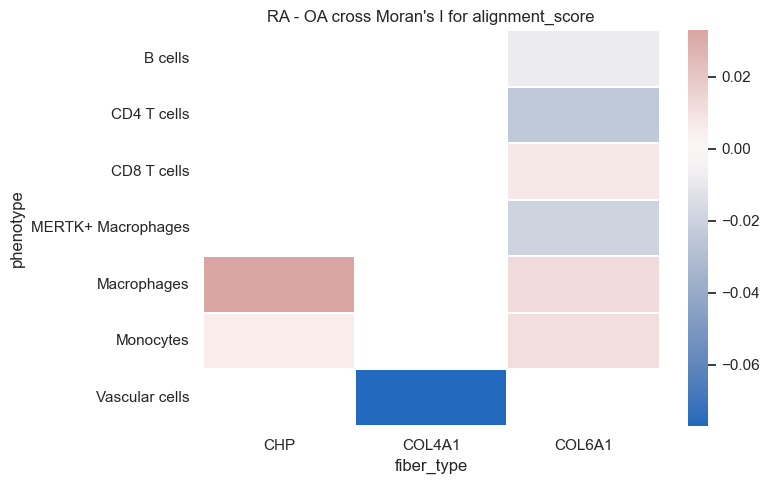

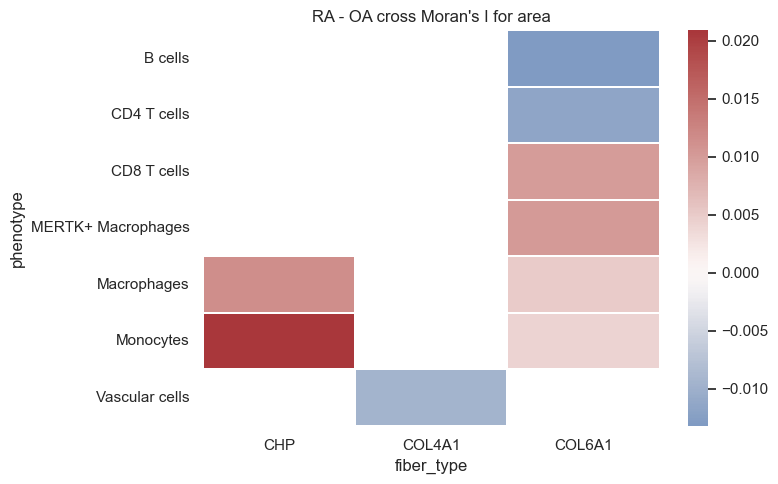

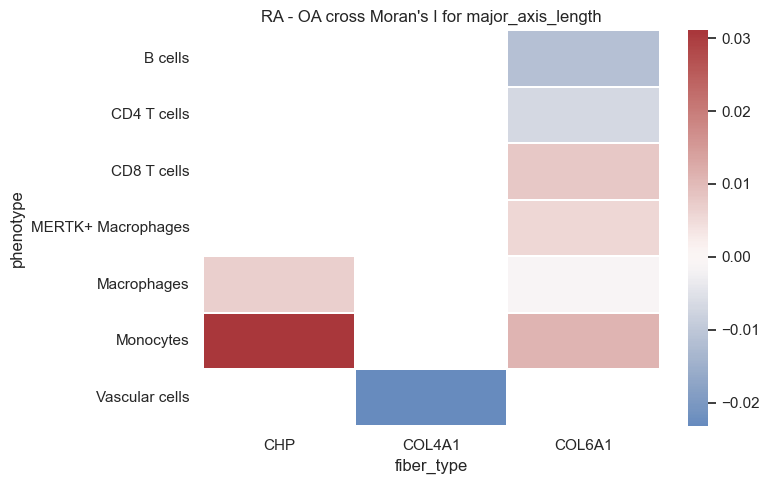

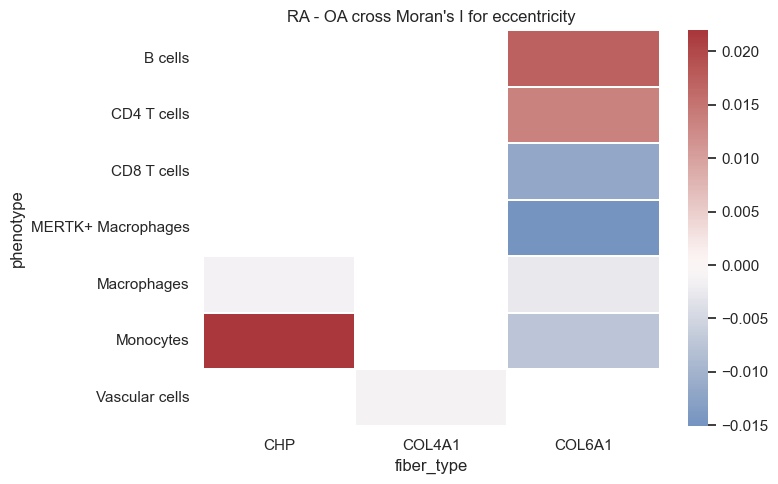

In [20]:
ra_oa_cross_moran = summarize_ra_oa(cross_moran_summary, "cross_morans_i", [PHENOTYPE_KEY, FIBER_TYPE_KEY, "feature_fiber"])
ra_oa_cross_moran.to_csv(ANALYSIS_DIR / "05_ra_oa_cross_moran_comparison.csv", index=False)
display(ra_oa_cross_moran.head(15))

for feature in CROSS_MORAN_FEATURES:
    feature_diff = ra_oa_cross_moran[ra_oa_cross_moran["feature_fiber"].eq(feature)].copy()
    feature_diff = add_pair_label(feature_diff)
    plot_heatmap(
        feature_diff,
        row=PHENOTYPE_KEY,
        col=FIBER_TYPE_KEY,
        value="RA_minus_OA",
        title=f"RA - OA cross Moran's I for {feature}",
        filename=f"05_ra_minus_oa_cross_moran_{safe_label(feature)}.png",
        figsize=(8, 5),
    )

In [21]:
RUN_CROSS_MORAN_PERMUTATIONS = False
CROSS_MORAN_N_SIM = 999
CROSS_MORAN_PERMUTATION_TESTS = [
    ("Monocytes", "COL6A1", "alignment_score"),
    ("CD4 T cells", "COL6A1", "alignment_score"),
    ("Macrophages", "CHP", "area"),
]
CROSS_MORAN_PERMUTATION_TESTS = [
    (p, f, ff) for p, f, ff in CROSS_MORAN_PERMUTATION_TESTS
    if p in EXISTING_PHENOTYPES and f in FIBER_TYPES and ff in FIBER_FEATURES
]

cross_moran_perm_rows = []

if RUN_CROSS_MORAN_PERMUTATIONS:
    for img in SAMPLE_IDS:
        obs_img_base = adata.obs.loc[adata.obs[IMAGE_KEY].eq(img)].copy()
        pathology = obs_img_base[GROUP_KEY].dropna().mode().iloc[0]
        fibers_img = fiber_df[fiber_df[IMAGE_KEY].eq(img)].copy()
        links_img = links_df[links_df[IMAGE_KEY].eq(img)].copy()

        for phenotype, fiber_type, feature_fiber in CROSS_MORAN_PERMUTATION_TESTS:
            feature_cell = f"is_{safe_label(phenotype)}"
            obs_img = obs_img_base.copy()
            obs_img[feature_cell] = obs_img[PHENOTYPE_KEY].eq(phenotype).astype(float)
            adata_img = ObsOnlyAnnData(obs_img)
            fibers_ft = fibers_img[fibers_img[FIBER_TYPE_KEY].eq(fiber_type)].copy()

            result = cross_morans_i_ecm_cells_permutation_test(
                adata_img,
                fibers_ft,
                links_img,
                feature_fiber=feature_fiber,
                cell_feature=feature_cell,
                k=KNN_K,
                n_sim=CROSS_MORAN_N_SIM,
                image_key=IMAGE_KEY,
                random_state=0,
            )
            result.update({
                IMAGE_KEY: img,
                GROUP_KEY: pathology,
                PHENOTYPE_KEY: phenotype,
                FIBER_TYPE_KEY: fiber_type,
                "feature_fiber": feature_fiber,
                "cell_feature": feature_cell,
            })
            cross_moran_perm_rows.append(result)

cross_moran_permutations = pd.DataFrame(cross_moran_perm_rows)
cross_moran_permutations.to_csv(ANALYSIS_DIR / "05_cross_morans_i_permutation_tests.csv", index=False)
display(cross_moran_permutations.head())

""


## 7. Optional local cross Moran hotspot map

Turn this on for one sample and one biological pair when you want a spatial map of ECM-cell coupling hotspots.

In [22]:
RUN_LOCAL_HOTSPOTS = False
HOTSPOT_IMAGE = SAMPLE_IDS[0]
HOTSPOT_PHENOTYPE = "Monocytes"
HOTSPOT_FIBER_TYPE = "COL6A1"
HOTSPOT_FIBER_FEATURE = "alignment_score"

if RUN_LOCAL_HOTSPOTS:
    obs_img = adata.obs.loc[adata.obs[IMAGE_KEY].eq(HOTSPOT_IMAGE)].copy()
    adata_img = ObsOnlyAnnData(obs_img)
    fibers_img = fiber_df[fiber_df[IMAGE_KEY].eq(HOTSPOT_IMAGE)].copy()
    fibers_ft = fibers_img[fibers_img[FIBER_TYPE_KEY].eq(HOTSPOT_FIBER_TYPE)].copy()
    links_img = links_df[links_df[IMAGE_KEY].eq(HOTSPOT_IMAGE)].copy()

    mapped = map_cells_to_fibers_kernel(
        adata_img,
        fibers_ft,
        links_img,
        phenotype_key=PHENOTYPE_KEY,
        phenotype=HOTSPOT_PHENOTYPE,
        bandwidth=CELL_FIBER_BANDWIDTH_PX,
    )
    cell_signal_col = f"{HOTSPOT_PHENOTYPE}_kernel_density"
    hotspot = local_cross_morans_i_ecm_cells(
        mapped,
        feature_fiber=HOTSPOT_FIBER_FEATURE,
        feature_cell=cell_signal_col,
        k=KNN_K,
        fiber_type_key=FIBER_TYPE_KEY,
        fiber_type=HOTSPOT_FIBER_TYPE,
    )
    local_col = f"local_cross_moran_{HOTSPOT_FIBER_FEATURE}_{cell_signal_col}"
    hotspot.to_pickle(ANALYSIS_DIR / "06_local_cross_moran_hotspot_example.pkl")

    fig, ax = plt.subplots(figsize=(7, 7))
    sc = ax.scatter(
        hotspot["X_centroid"],
        hotspot["Y_centroid"],
        c=hotspot[local_col],
        s=3,
        cmap="vlag",
        alpha=0.85,
    )
    ax.set_title(f"{HOTSPOT_IMAGE}: {HOTSPOT_PHENOTYPE} x {HOTSPOT_FIBER_TYPE} local cross Moran")
    ax.set_aspect("equal", adjustable="box")
    ax.invert_yaxis()
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    fig.colorbar(sc, ax=ax, label="Local cross Moran's I")
    sns.despine(ax=ax)
    savefig(fig, "06_local_cross_moran_hotspot_example.png")
    plt.show()

## Optional ECM graph niches

This block asks whether graph-derived ECM communities recover COL6A1-rich/poor immune niches.

It builds cell-fiber graphs, projects them onto fibers, detects Louvain communities, then summarizes each graph niche by:

- dominant ECM fiber type;
- fraction of fibers in COL6A1-rich or COL6A1-poor regions;
- nearby immune-cell composition from linked cells.

This can be heavy on the full dataset, so run it after reviewing the simpler region, Ripley, and Moran analyses.

In [23]:
RUN_ECM_GRAPH_NICHES = False

if RUN_ECM_GRAPH_NICHES:
    graphs = build_ecm_bipartite_graph_per_image(
        adata,
        fiber_df,
        links_df,
        image_key=IMAGE_KEY,
        link_image_key=IMAGE_KEY,
        distance_scale=CELL_FIBER_BANDWIDTH_PX,
        include_cell_attrs=False,
        include_fiber_attrs=False,
    )
    fiber_graphs = project_fiber_graph_per_image(graphs)
    niche_maps = detect_ecm_niches_per_image(fiber_graphs, weight="weight", resolution=1.0, random_state=0)
    fiber_with_niches = assign_niches_to_fibers(fiber_col6_regions, niche_maps, image_key=IMAGE_KEY)
    fiber_with_niches.to_pickle(ANALYSIS_DIR / "07_fiber_with_ecm_graph_niches.pkl")

    niche_fiber_summary = (
        fiber_with_niches.dropna(subset=["niche"])
        .groupby([IMAGE_KEY, GROUP_KEY, "niche", FIBER_TYPE_KEY, "COL6A1_region"], observed=True)
        .size()
        .reset_index(name="n_fibers")
    )
    niche_fiber_summary.to_csv(ANALYSIS_DIR / "07_graph_niche_fiber_summary.csv", index=False)

    niche_links = links_df.merge(
        fiber_with_niches[["niche", "COL6A1_region"]],
        left_on="fiber_id",
        right_index=True,
        how="inner",
    )
    niche_cells = niche_links.merge(
        adata.obs[[GROUP_KEY, PHENOTYPE_KEY]],
        left_on="cell_id",
        right_index=True,
        how="left",
    )
    niche_cells = niche_cells.drop_duplicates([IMAGE_KEY, "niche", "cell_id"])
    niche_cell_counts = (
        niche_cells[niche_cells[PHENOTYPE_KEY].isin(PAPER_CELL_TYPES)]
        .groupby([IMAGE_KEY, GROUP_KEY, "niche", PHENOTYPE_KEY], observed=True)
        .size()
        .reset_index(name="n_cells")
    )
    totals = niche_cell_counts.groupby([IMAGE_KEY, GROUP_KEY, "niche"], observed=True)["n_cells"].transform("sum")
    niche_cell_counts["fraction"] = niche_cell_counts["n_cells"] / totals
    niche_cell_counts.to_csv(ANALYSIS_DIR / "07_graph_niche_cell_composition.csv", index=False)

    display(niche_fiber_summary.head())
    display(niche_cell_counts.head())
else:
    fiber_with_niches = None

## Outputs

The notebook saves result tables to `notebooks/results/ra_oa_ecm_cell/paper_guided_outputs` and figures to `notebooks/results/ra_oa_ecm_cell/figures/01_paper_guided_analysis`.

The highest-priority tables for interpretation are:

- `01_ra_oa_distance_comparison.csv`
- `01_ra_oa_density_comparison.csv`
- `02_col6_zone_cell_frequencies.csv`
- `02_col6_zone_area_summary.csv`
- `02_col6_region_cell_density_per_area.csv`
- `02_ra_oa_col6_region_cell_density_comparison.csv`
- `03_cross_ripley_paper_guided_curves.csv`
- `04_perivascular_col6_cell_signals.csv`
- `04_perivascular_cross_moran.csv`
- `04_ra_oa_col6_region_fiber_moran_comparison.csv`
- `05_ra_oa_cross_moran_comparison.csv`
- optional graph outputs beginning with `07_...`